In [5]:
pip install rioxarray

Note: you may need to restart the kernel to use updated packages.


# **VEGETATION INDICES**

Membaca file mask sawah lokal...
Mengambil citra Sentinel-2 terbaru (Juli 2026)...
-> Glosarium indeks disimpan: Keterangan_Indeks_Vegetasi.json

=== Memproses & mengekspor Data Spasial (GeoJSON & COG) per indeks ===
Mengunduh dan menyatukan tile untuk: sawah_evi.tif...
   -> Menerapkan majority filter 5x5 pada kelas kuantil EVI...
   -> EVI: GeoJSON & COG berhasil diekspor dengan bersih.
Mengunduh dan menyatukan tile untuk: sawah_msavi.tif...
   -> Menerapkan majority filter 5x5 pada kelas kuantil MSAVI...
   -> MSAVI: GeoJSON & COG berhasil diekspor dengan bersih.
Mengunduh dan menyatukan tile untuk: sawah_rdvi.tif...
   -> Menerapkan majority filter 5x5 pada kelas kuantil RDVI...
   -> RDVI: GeoJSON & COG berhasil diekspor dengan bersih.
Mengunduh dan menyatukan tile untuk: sawah_gndvi.tif...
   -> Menerapkan majority filter 5x5 pada kelas kuantil GNDVI...
   -> GNDVI: GeoJSON & COG berhasil diekspor dengan bersih.
Mengunduh dan menyatukan tile untuk: sawah_ndre.tif...
   -> Menerap

## 📊 Pratinjau Hasil Analisis Indeks Vegetasi & Biofisik Sawah

**Tanggal Citra Utama:** 2026-07-26 | **Jumlah Indeks:** 7

### 📈 Time Series Indeks Spektral (halus, tersambung)

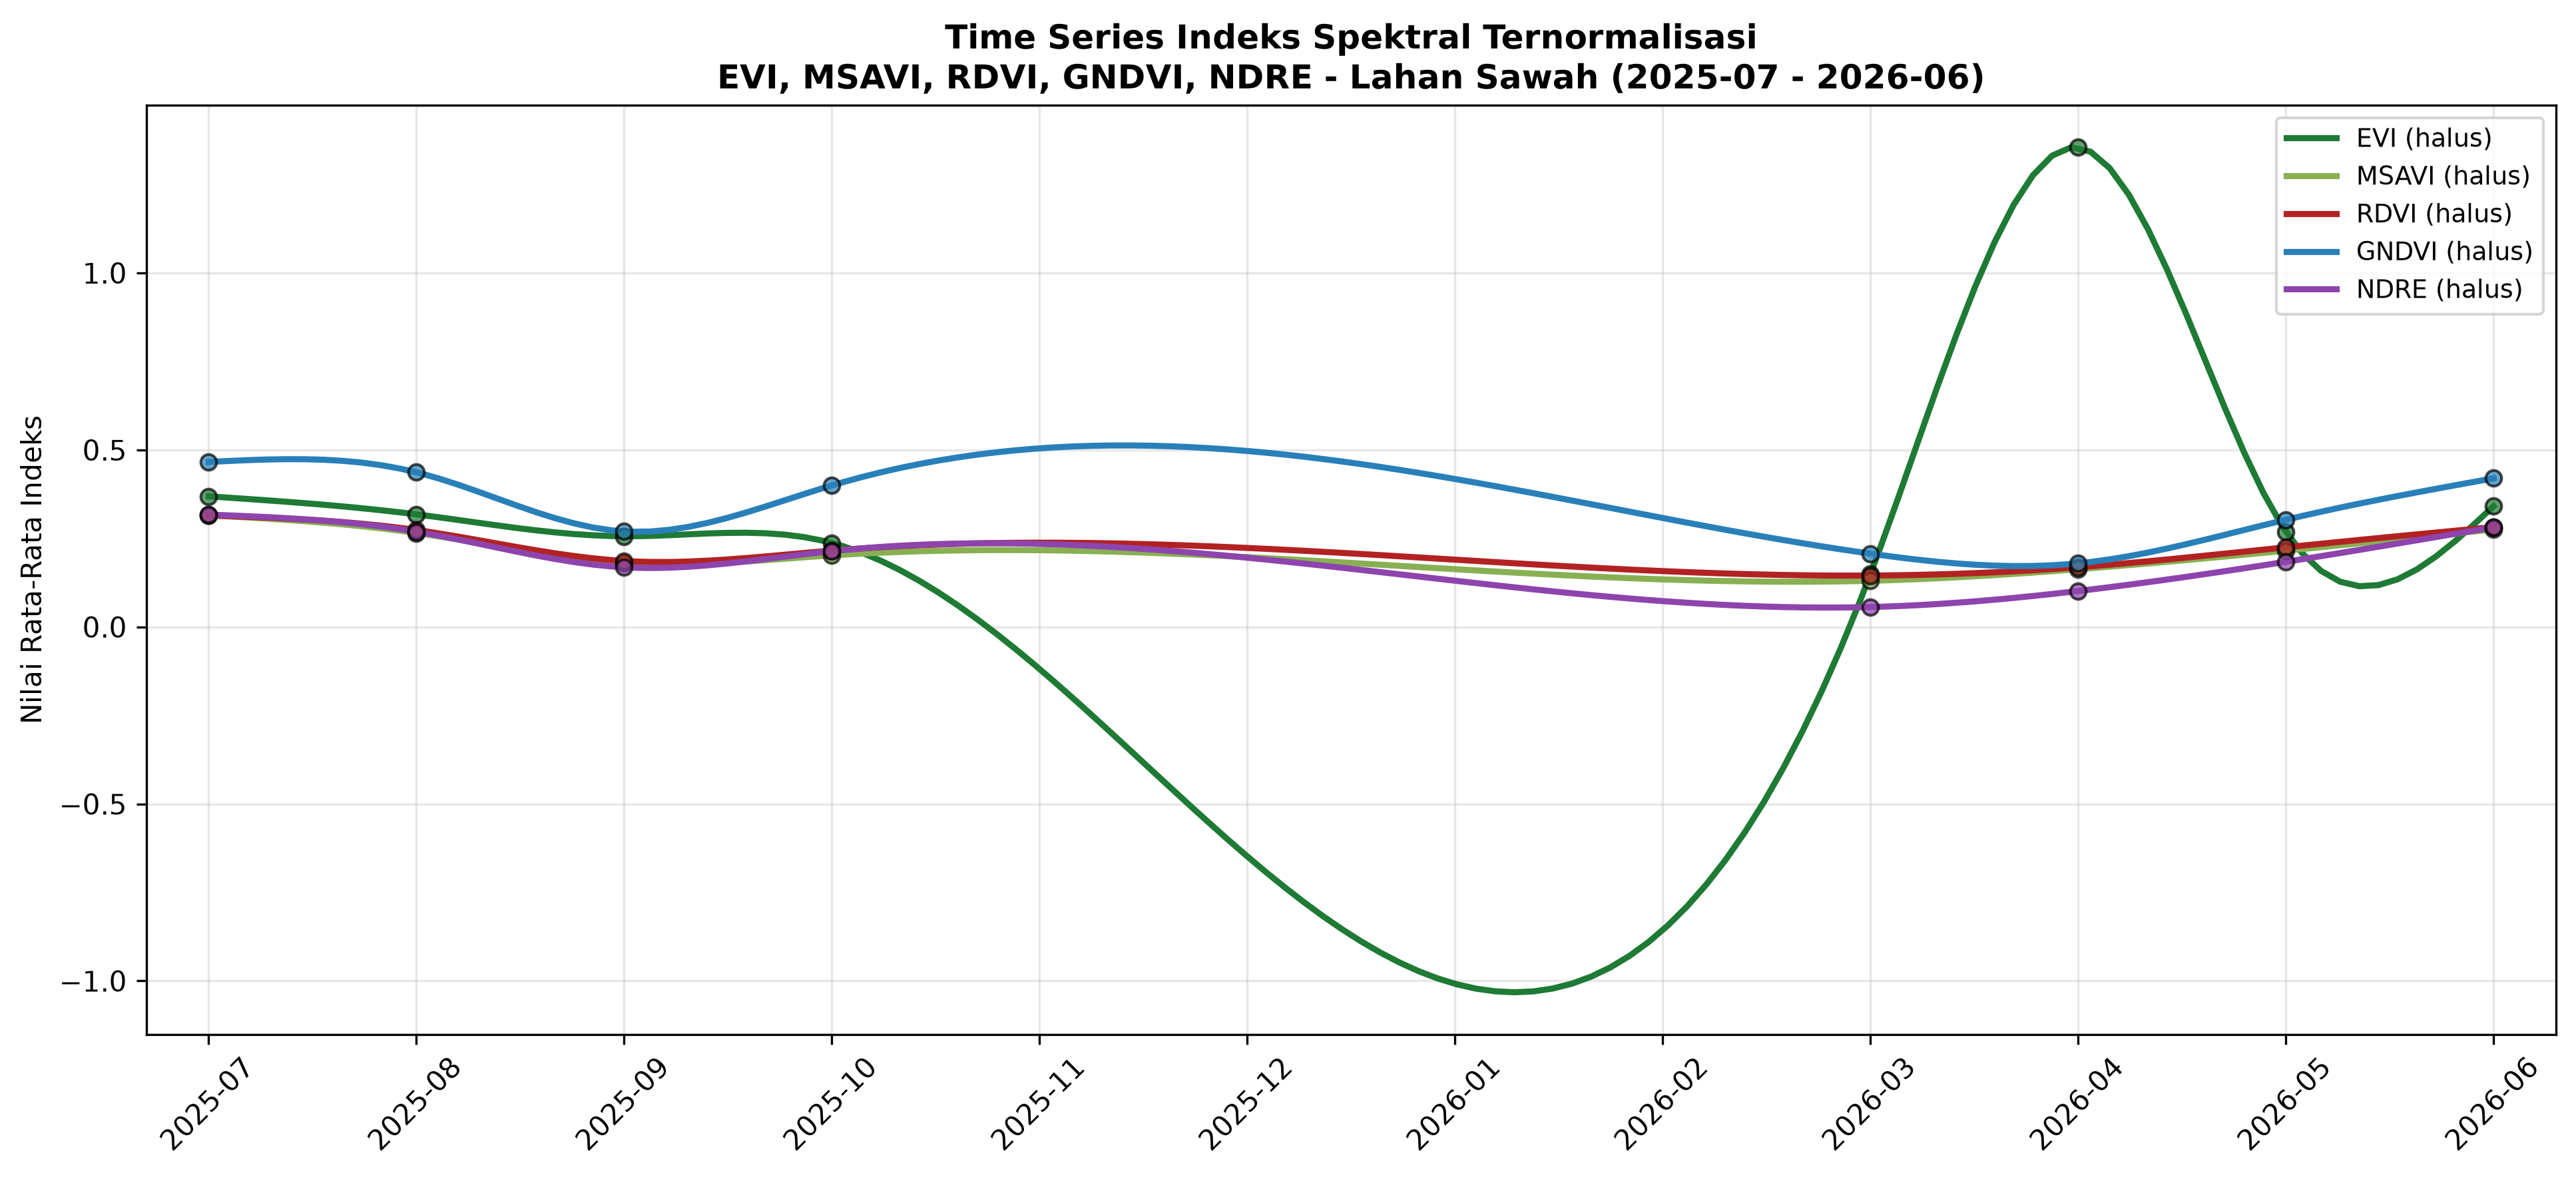

### 📈 Time Series Estimasi Biofisik: LAI vs AGB (halus, tersambung)

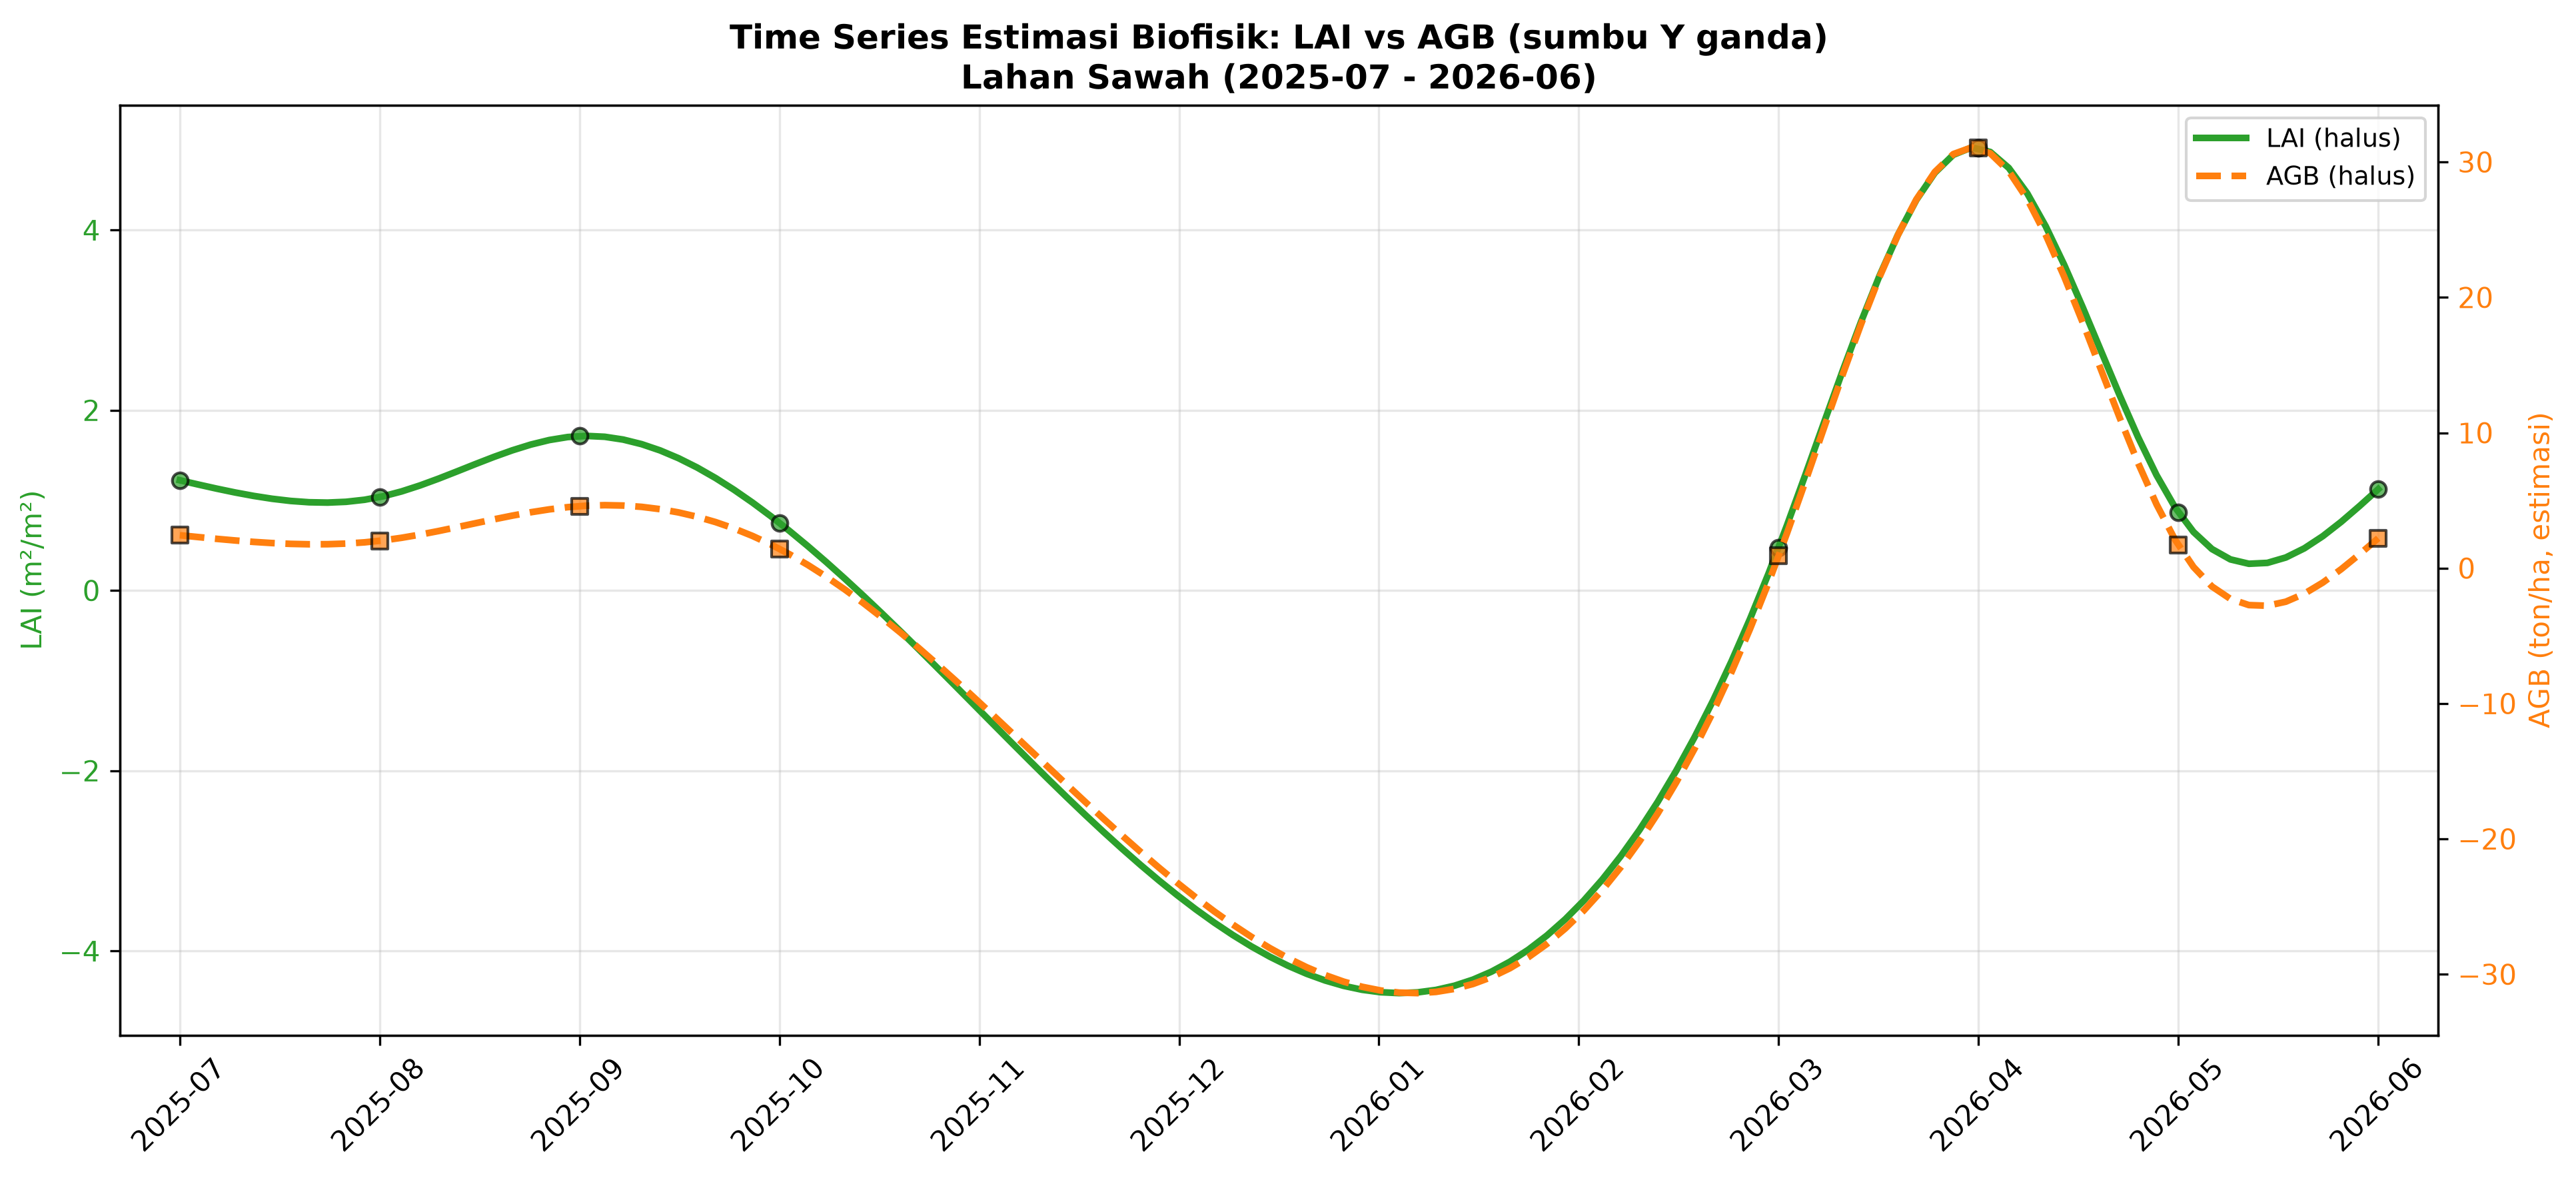

### 📖 Keterangan Setiap Indeks & Estimasi Biofisik

**EVI — Enhanced Vegetation Index**

Indeks vegetasi yang dioptimalkan utk mengurangi pengaruh atmosfer & latar belakang tanah, serta mengoreksi saturasi sinyal yang sering terjadi pd NDVI di kanopi rapat.

*Rumus:* `2.5 x (NIR - Red) / (NIR + 6 x Red - 7.5 x Blue + 1)`  
*Manfaat:* Memantau kerapatan & kondisi kanopi tanaman padi, khususnya pd fase pertumbuhan puncak ketika indeks berbasis NDVI mulai jenuh (tidak lagi peka thd penambahan biomassa).  
*Satuan:* Tanpa satuan (indeks, umumnya 0 - 1 pd vegetasi sehat)

**MSAVI — Modified Soil-Adjusted Vegetation Index**

Turunan SAVI yang secara otomatis menyesuaikan faktor koreksi tanah tanpa kalibrasi manual, sehingga meminimalkan pengaruh warna & kelembapan tanah/genangan terhadap estimasi vegetasi.

*Rumus:* `(2N+1 - akar((2N+1)^2 - 8(N-R))) / 2`  
*Manfaat:* Cocok utk memantau fase awal tanam sawah ketika tutupan vegetasi masih jarang & tanah atau genangan air masih dominan terlihat oleh sensor.  
*Satuan:* Tanpa satuan (indeks)

**RDVI — Renormalized Difference Vegetation Index**

Menggabungkan kepekaan NDVI pd vegetasi jarang dgn kestabilan DVI pd vegetasi rapat, sehingga performanya lebih konsisten di seluruh rentang kerapatan tanaman.

*Rumus:* `(NIR - Red) / akar(NIR + Red)`  
*Manfaat:* Baik dipakai utk pemantauan yang mencakup berbagai fase pertumbuhan sekaligus (dari tanam hingga menjelang panen) krn tidak mudah jenuh seperti NDVI biasa.  
*Satuan:* Tanpa satuan (indeks)

**GNDVI — Green Normalized Difference Vegetation Index**

Mirip NDVI, tapi memakai band hijau (bukan merah) sehingga lebih peka terhadap kandungan klorofil daun.

*Rumus:* `(NIR - Green) / (NIR + Green)`  
*Manfaat:* Berguna utk deteksi dini stres nutrisi (khususnya nitrogen) krn kandungan klorofil menurun lebih dulu sebelum gejala terlihat kasat mata di lapangan.  
*Satuan:* Tanpa satuan (indeks, rentang -1 s.d. 1)

**NDRE — Normalized Difference Red Edge**

Memanfaatkan band red-edge yang tetap peka thd kandungan klorofil pd kanopi yang sudah cukup rapat, tempat NDVI biasa mulai jenuh.

*Rumus:* `(NIR - RedEdge) / (NIR + RedEdge)`  
*Manfaat:* Sangat berguna utk pemantauan status nitrogen tanaman pd fase vegetatif lanjut hingga menjelang pengisian bulir.  
*Satuan:* Tanpa satuan (indeks, rentang -1 s.d. 1)

**LAI — Leaf Area Index**

Estimasi rasio luas total permukaan daun (satu sisi) terhadap luas lahan di bawahnya. Pd skrip ini, LAI diestimasi scr empiris dari EVI (bukan pengukuran langsung).

*Rumus:* `LAI = 3.618 x EVI - 0.118 (regresi empiris, ilustratif)`  
*Manfaat:* Indikator kapasitas fotosintesis & penyerapan cahaya kanopi; dipakai sbg input model pertumbuhan tanaman & estimasi produktivitas panen.  
*Satuan:* m2/m2 (luas daun per luas lahan)  
*Catatan:* Formula bersifat regresi empiris generik, bukan hasil kalibrasi lapangan setempat -> sebaiknya divalidasi/dikalibrasi ulang dgn sampel lapangan lokal sebelum dipakai utk keputusan kuantitatif.

**AGB — Above Ground Biomass**

Estimasi total massa bahan organik tanaman (batang, daun, malai) yang berada di atas permukaan tanah. Pd skrip ini, AGB diestimasi scr empiris dari LAI.

*Rumus:* `AGB = 1.9 x LAI^1.1 (regresi empiris, ilustratif)`  
*Manfaat:* Dipakai utk memperkirakan potensi hasil panen (yield), memantau pertumbuhan biomassa dari waktu ke waktu, & mendukung estimasi stok karbon vegetasi.  
*Satuan:* ton/ha  
*Catatan:* Sama seperti LAI, formula ini bersifat regresi empiris generik dan sebaiknya dikalibrasi ulang dgn data panen lapangan setempat utk akurasi kuantitatif.

**Kelas abu-abu (Non-Sawah)** — Area di dalam cakupan citra yang berada di luar batas mask sawah (mis. permukiman, jalan, badan air, vegetasi non-padi, dsb). Bukan hasil klasifikasi indeks, melainkan penanda konteks spasial.

### 🗺️ Pratinjau Spasial per Indeks (5 kelas kuantil + kelas Non-Sawah)

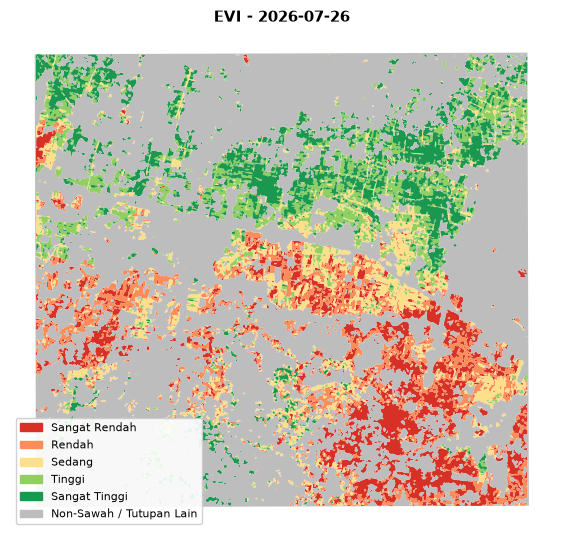

*File Vektor: `../../data/processed\module_3\Klasifikasi_EVI_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_EVI_2026-07-26.tif`*

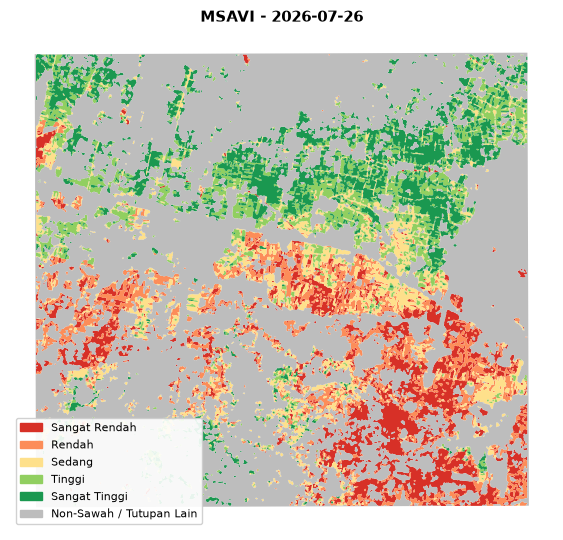

*File Vektor: `../../data/processed\module_3\Klasifikasi_MSAVI_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_MSAVI_2026-07-26.tif`*

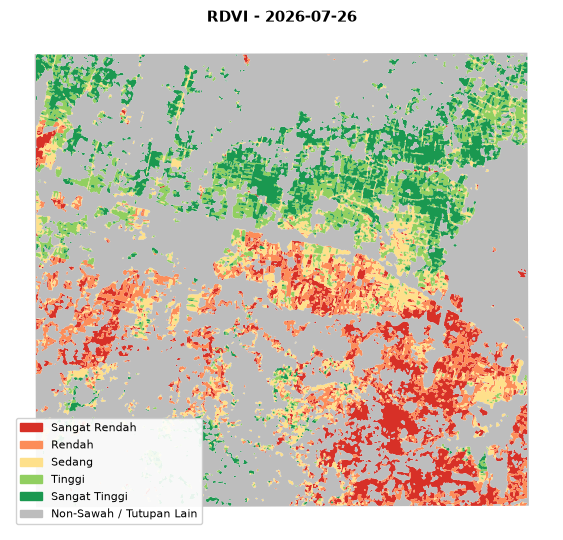

*File Vektor: `../../data/processed\module_3\Klasifikasi_RDVI_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_RDVI_2026-07-26.tif`*

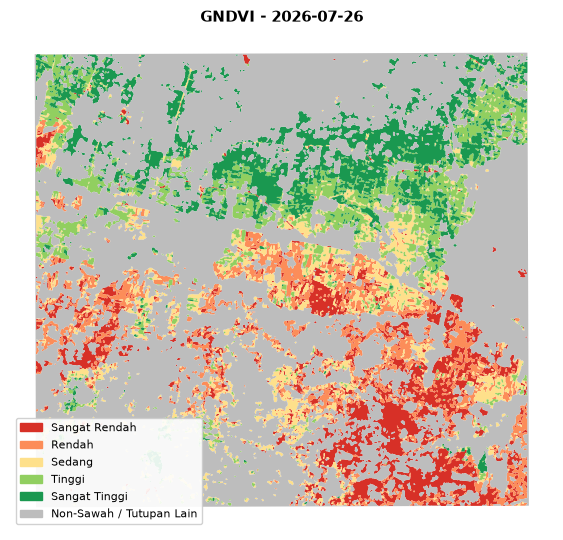

*File Vektor: `../../data/processed\module_3\Klasifikasi_GNDVI_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_GNDVI_2026-07-26.tif`*

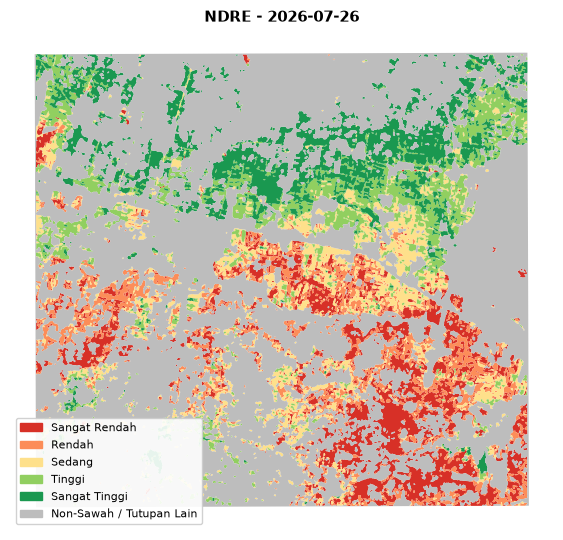

*File Vektor: `../../data/processed\module_3\Klasifikasi_NDRE_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_NDRE_2026-07-26.tif`*

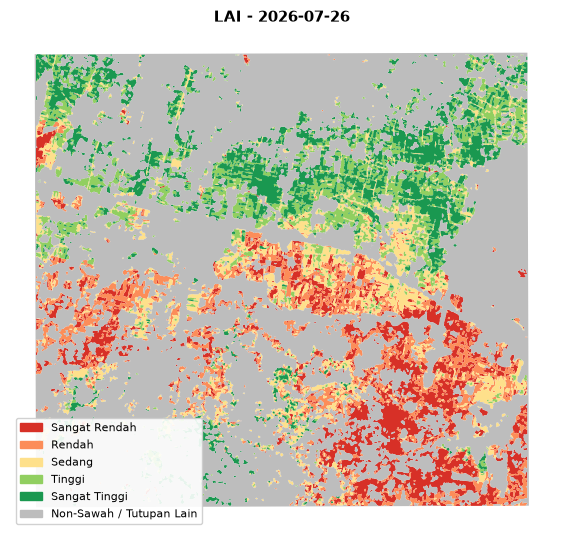

*File Vektor: `../../data/processed\module_3\Klasifikasi_LAI_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_LAI_2026-07-26.tif`*

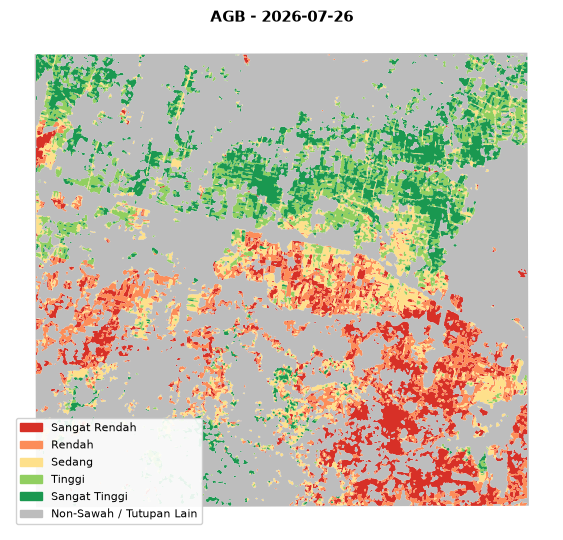

*File Vektor: `../../data/processed\module_3\Klasifikasi_AGB_2026-07-26.geojson` | File Raster: `../../data/processed\module_3\Klasifikasi_AGB_2026-07-26.tif`*


=== SEMUA PROSES DAN PRATINJAU SELESAI ===


In [6]:
"""
================================================================================
ANALISIS INDEKS VEGETASI & ESTIMASI BIOFISIK LAHAN SAWAH (GEE)
REVISI 2: + KELAS "NON-SAWAH" (ABU-ABU) UTK AREA DI LUAR MASK,
          + MAJORITY FILTER DIAKTIFKAN (sebelumnya terdefinisi tapi tidak
            pernah dipanggil di pipeline utama),
          + GLOSARIUM/KETERANGAN TIAP INDEKS (nama lengkap, definisi, rumus,
            manfaat, satuan) -> dilampirkan otomatis sbg properti tiap fitur
            GeoJSON (siap dipakai tooltip hover di peta web) + disimpan juga
            sbg file JSON terpisah utk panel info/legenda.
REVISI 1 (bawaan): ditambahkan klasifikasi KUANTIL yang sebelumnya hilang,
        dan pemanggilan fungsi ekspor spasial diperbaiki agar cocok dengan
        definisinya (lihat komentar "# [FIX]").
================================================================================
"""

import ee
import os
import json
import datetime
import urllib.request
import numpy as np
import rasterio
import rasterio.features
from rasterio.merge import merge
from rasterio.features import shapes as rio_shapes
import rioxarray
import xarray as xr
import geopandas as gpd
from shapely.geometry import shape as shapely_shape
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.interpolate import CubicSpline, interp1d
from IPython.display import Image, display, Markdown
from scipy.ndimage import convolve

# --- OPSIONAL: majority filter pasca-klasifikasi kuantil ---
TERAPKAN_MAJORITY_FILTER = True
UKURAN_JENDELA_MAJORITY = 5

# ==========================================
# 1. INISIALISASI & KONFIGURASI AWAL
# ==========================================
ee.Authenticate() # Jalankan jika belum autentikasi
ee.Initialize(project='poetic-emblem-487109-t6')

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_3"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

file_mask_sawah = os.path.join(PROCESSED_DIR, 'module_1', 'Klasifikasi_Sawah.tif')
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_3")
os.makedirs(MODULE_DIR, exist_ok=True)
FOLDER_CACHE = os.path.join(MODULE_DIR, "cache_indeks_vegetasi")
os.makedirs(FOLDER_CACHE, exist_ok=True)

NODATA = 255

# --- Indeks dikelompokkan berdasarkan skala nilainya ---
VI_LIST_NORMALIZED = ['EVI', 'MSAVI', 'RDVI', 'GNDVI', 'NDRE']
VI_LIST_DERIVED = ['LAI', 'AGB']
VI_LIST = VI_LIST_NORMALIZED + VI_LIST_DERIVED

# --- Klasifikasi kuantil utk ekspor Spasial ---
N_KELAS_GEOJSON = 5
LABEL_KELAS_KUANTIL = ["Sangat Rendah", "Rendah", "Sedang", "Tinggi", "Sangat Tinggi"]
WARNA_KELAS_KUANTIL = ["#D73027", "#FC8D59", "#FEE08B", "#91CF60", "#1A9850"]

# --- [BARU] Kelas khusus utk area NON-SAWAH di dalam cakupan citra ---
# Nilai kelas ini sengaja diset = N_KELAS_GEOJSON (mis. 5) agar TIDAK PERNAH
# bentrok dengan kelas kuantil hasil np.digitize (yang selalu berada pada
# rentang 0 .. N_KELAS_GEOJSON-1, bahkan bila breakpoint kuantil ada yg
# kembar sehingga jumlah kelas aktual < N_KELAS_GEOJSON). Sebelumnya, piksel
# di luar mask sawah diberi NaN -> tidak ikut dipoligonisasi -> muncul area
# kosong/putih pada GeoJSON/COG saat ditampilkan di web (lihat gambar yang
# diunggah). Sekarang piksel tsb diberi kelas tersendiri berwarna abu-abu.
NILAI_KELAS_NONSAWAH = N_KELAS_GEOJSON
LABEL_KELAS_KUANTIL_LENGKAP = LABEL_KELAS_KUANTIL + ["Non-Sawah / Tutupan Lain"]
WARNA_KELAS_KUANTIL_LENGKAP = WARNA_KELAS_KUANTIL + ["#BDBDBD"]  # abu-abu netral

print("Membaca file mask sawah lokal...")
mask_daerah = rioxarray.open_rasterio(file_mask_sawah)
template_2d = mask_daerah.squeeze()
bounds = mask_daerah.rio.bounds()  # (minx, miny, maxx, maxy)

mask_wgs84 = mask_daerah.rio.reproject("EPSG:4326")
wgs84_bounds = mask_wgs84.rio.bounds()
aoi_ee = ee.Geometry.Rectangle([wgs84_bounds[0], wgs84_bounds[1], wgs84_bounds[2], wgs84_bounds[3]])
sawah_mask_2d = (template_2d == 1)

# ==========================================
# 2. FUNGSI BANTUAN TILING & DOWNLOAD GEE
# ==========================================
def unduh_raster_ee_per_band(ee_image, aoi_geometry, nama_file_output, scale=10):
    """Unduh 1 band dgn tiling 2x2 (menghindari batas ukuran getDownloadURL GEE), lalu mosaik lokal."""
    print(f"Mengunduh dan menyatukan tile untuk: {nama_file_output}...")
    bounds_geom = aoi_geometry.bounds().getInfo()['coordinates'][0]
    minx, miny = min([p[0] for p in bounds_geom]), min([p[1] for p in bounds_geom])
    maxx, maxy = max([p[0] for p in bounds_geom]), max([p[1] for p in bounds_geom])

    n_split = 2
    x_steps = np.linspace(minx, maxx, n_split + 1)
    y_steps = np.linspace(miny, maxy, n_split + 1)
    temp_files = []

    for i in range(n_split):
        for j in range(n_split):
            sub_box = ee.Geometry.Rectangle([x_steps[i], y_steps[j], x_steps[i+1], y_steps[j+1]])
            try:
                url = ee_image.getDownloadURL({
                    'scale': scale,
                    'crs': 'EPSG:4326',
                    'region': sub_box,
                    'format': 'GEO_TIFF'
                })
                sub_file = os.path.join(FOLDER_CACHE, f"temp_tile_{i}_{j}_{nama_file_output}")
                urllib.request.urlretrieve(url, sub_file)
                temp_files.append(sub_file)
            except Exception as e:
                pass

    if not temp_files:
        raise RuntimeError(f"Gagal mengunduh {nama_file_output}")

    src_files_to_mosaic = [rasterio.open(f) for f in temp_files]
    mosaic, out_trans = merge(src_files_to_mosaic)
    meta = src_files_to_mosaic[0].meta.copy()
    for src in src_files_to_mosaic:
        src.close()

    meta.update({"height": mosaic.shape[1], "width": mosaic.shape[2], "transform": out_trans})

    path_out = os.path.join(FOLDER_CACHE, nama_file_output)
    with rasterio.open(path_out, "w", **meta) as dest:
        dest.write(mosaic)

    for f in temp_files:
        if os.path.exists(f):
            os.remove(f)

    da = rioxarray.open_rasterio(path_out).rio.reproject_match(mask_daerah)
    return da


def bersihkan_outlier(arr, batas_bawah, batas_atas):
    """Menggantikan piksel di luar rentang wajar dgn NaN (nilai tdk fisikal)."""
    arr_clean = np.where((arr < batas_bawah) | (arr > batas_atas), np.nan, arr)
    return arr_clean


# ==========================================
# 2A. KLASIFIKASI KUANTIL
# ==========================================
def klasifikasi_kuantil(arr, n_kelas=N_KELAS_GEOJSON, label_list=LABEL_KELAS_KUANTIL):
    """
    Mengubah array nilai kontinu (EVI, MSAVI, LAI, dst - float, bisa negatif/desimal)
    menjadi kelas integer 0..n_kelas-1 berdasarkan breakpoint kuantil.

    Tanpa fungsi ini, nilai float (mis. EVI = 0.42, MSAVI = -0.08, dst) akan
    langsung di-cast paksa ke uint8 di ekspor_spasial_dengan_sieve().
    astype(np.uint8) MEMOTONG desimal, bukan mengklasifikasi -> hampir semua
    piksel jadi kelas 0 secara acak mengikuti bagian desimalnya, sehingga
    batas poligon mengikuti pola noise piksel-per-piksel (GeoJSON pecah jadi
    ribuan segitiga kecil).

    Return: (kelas_arr [float, NaN dipertahankan], dict_label, dict_rentang)
    """
    valid = arr[~np.isnan(arr)]
    if valid.size == 0:
        return arr.astype(float), {}, {}

    persen = np.linspace(0, 100, n_kelas + 1)
    breaks = np.nanpercentile(valid, persen)
    breaks = np.unique(breaks)  # jaga2 kalau ada breakpoint kembar (data terlalu seragam)

    if len(breaks) < 2:
        # semua nilai valid identik -> jadikan satu kelas saja
        kelas_arr = np.where(np.isnan(arr), np.nan, 0.0)
        dict_label = {0: label_list[0]}
        dict_rentang = {0: f"{valid.min():.3f} - {valid.max():.3f}"}
        return kelas_arr, dict_label, dict_rentang

    n_aktual = len(breaks) - 1
    # bins tengah (tanpa batas pertama & terakhir) untuk np.digitize
    kelas_int = np.digitize(arr, breaks[1:-1], right=False)
    kelas_arr = np.where(np.isnan(arr), np.nan, kelas_int).astype(float)

    dict_label = {i: label_list[i] if i < len(label_list) else f"Kelas {i}" for i in range(n_aktual)}
    dict_rentang = {i: f"{breaks[i]:.3f} - {breaks[i+1]:.3f}" for i in range(n_aktual)}

    return kelas_arr, dict_label, dict_rentang


def majority_filter_kuantil(kelas_arr, ukuran_jendela=5):
    """
    Majority filter (mode) utk array kelas kuantil (float, NaN = piksel invalid).
    Piksel NaN tidak ikut dihitung sbg tetangga & tetap NaN pd hasil akhir.
    Efisien: hitung jumlah tetangga per kelas via konvolusi (jumlah kelas
    kuantil kecil, mis. 5), lalu tiap piksel diberi kelas dgn hitungan
    tertinggi di jendelanya (argmax).
    """
    mask_valid = ~np.isnan(kelas_arr)
    kelas_ada = np.unique(kelas_arr[mask_valid]).astype(int)
    if kelas_ada.size == 0:
        return kelas_arr.copy()

    kernel = np.ones((ukuran_jendela, ukuran_jendela), dtype=np.float32)
    tumpukan_count = np.zeros((len(kelas_ada),) + kelas_arr.shape, dtype=np.float32)

    for i, k in enumerate(kelas_ada):
        biner_k = ((kelas_arr == k) & mask_valid).astype(np.float32)
        tumpukan_count[i] = convolve(biner_k, kernel, mode="constant", cval=0)

    idx_menang = np.argmax(tumpukan_count, axis=0)
    hasil = kelas_ada[idx_menang].astype(float)
    hasil[~mask_valid] = np.nan
    return hasil

# ==========================================
# 2B. EKSPOR SPASIAL (GeoJSON & COG) + SIEVE
# ==========================================
def ekspor_spasial_dengan_sieve(arr_in, template_da, dict_label, dict_rentang,
                                 nama_layer, path_geojson, path_cog,
                                 info_indeks=None, info_nonsawah=None,
                                 nilai_kelas_nonsawah=None):
    transform = template_da.rio.transform()
    crs = template_da.rio.crs

    # 1. Tangani nilai NaN / NODATA
    kelas_u8 = np.where(np.isnan(arr_in), NODATA, arr_in).astype(np.uint8)
    mask_valid = (kelas_u8 != NODATA)

    # --- 2. SIMPAN SEBAGAI COG (RASTER) ---
    # COG dibuat dari data kelas hasil klasifikasi kuantil + kelas non-sawah
    # (bukan nilai indeks mentah)
    da_kelas = xr.DataArray(kelas_u8, dims=template_da.dims, coords=template_da.coords)
    da_kelas = da_kelas.rio.write_transform(transform)
    da_kelas = da_kelas.rio.write_crs(crs)
    da_kelas = da_kelas.rio.write_nodata(NODATA)
    da_kelas.rio.to_raster(path_cog, driver="COG", compress="DEFLATE")

    # --- 3. TERAPKAN SIEVE FILTER UNTUK VEKTOR (GEOJSON) ---
    # size=20 artinya kelompok piksel di bawah 20 piksel (~0.2 Ha) akan dilebur
    # ke kelas dominan di sekitarnya sehingga GeoJSON tidak pecah-pecah/berantakan.
    kelas_sieved = rasterio.features.sieve(kelas_u8, size=20, mask=mask_valid, connectivity=4)

    # --- 4. POLIGONISASI ---
    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(kelas_sieved, mask=(kelas_sieved != NODATA), transform=transform, connectivity=4)
    ]

    if not records:
        print(f"   [Peringatan] {nama_layer}: tidak ada fitur terpoligonisasi.")
        return None

    gdf = gpd.GeoDataFrame(records, crs=crs)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    # --- 5. HINDARI SIMPLIFY BERLEBIHAN ---
    toleransi_simplify_m = 0
    if toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    gdf["luas_ha"] = (gdf.geometry.area / 10000).round(2)
    gdf["label"] = gdf["kelas"].map(dict_label)
    gdf["rentang_nilai"] = gdf["kelas"].map(dict_rentang)
    gdf["indeks"] = nama_layer

    # --- 6. [BARU] Lampirkan keterangan/definisi indeks ke SETIAP fitur.
    #     Tujuannya supaya file GeoJSON ini bisa langsung dipakai sbg sumber
    #     tooltip saat kursor hover di peta web, tanpa perlu fetch data
    #     tambahan dari file lain. ---
    if info_indeks:
        gdf["nama_lengkap"] = info_indeks.get("nama_lengkap", "")
        gdf["definisi"] = info_indeks.get("definisi", "")
        gdf["manfaat"] = info_indeks.get("manfaat", "")
        gdf["satuan"] = info_indeks.get("satuan", "")

    # Utk baris berkelas "Non-Sawah", timpa dgn keterangan yg sesuai
    if nilai_kelas_nonsawah is not None and info_nonsawah:
        m = gdf["kelas"] == nilai_kelas_nonsawah
        gdf.loc[m, "nama_lengkap"] = info_nonsawah.get("nama_lengkap", "")
        gdf.loc[m, "definisi"] = info_nonsawah.get("definisi", "")
        gdf.loc[m, "manfaat"] = info_nonsawah.get("manfaat", "")
        gdf.loc[m, "satuan"] = info_nonsawah.get("satuan", "")

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_geojson, driver="GeoJSON")
    print(f"   -> {nama_layer}: GeoJSON & COG berhasil diekspor dengan bersih.")

    return gdf


# ==========================================
# 3. PENGAMBILAN CITRA TERBARU & PERHITUNGAN INDEKS
# ==========================================
print("Mengambil citra Sentinel-2 terbaru (Juli 2026)...")
s2_juli2026 = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
    .filterBounds(aoi_ee) \
    .filterDate('2026-07-01', '2026-07-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .sort('system:time_start', False) \
    .first() \
    .clip(aoi_ee)

tanggal_citra = ee.Date(s2_juli2026.get('system:time_start')).format('YYYY-MM-dd').getInfo()

img_scaled = s2_juli2026.multiply(0.0001)
dict_b = {
    'N': img_scaled.select('B8'),    # NIR
    'R': img_scaled.select('B4'),    # Red
    'G': img_scaled.select('B3'),    # Green
    'B': img_scaled.select('B2'),    # Blue
    'RE': img_scaled.select('B5'),   # Red Edge (untuk NDRE)
}

EPS = 1e-6  # epsilon anti divide-by-near-zero

# --- Indeks spektral dasar ---
evi = img_scaled.expression(
    '2.5 * (N - R) / (N + 6 * R - 7.5 * B + 1 + EPS)', {**dict_b, 'EPS': EPS}
).rename('EVI')

msavi = img_scaled.expression(
    '(2 * N + 1 - sqrt((2 * N + 1) * (2 * N + 1) - 8 * (N - R))) / 2', dict_b
).rename('MSAVI')

rdvi = img_scaled.expression('(N - R) / sqrt(N + R)', dict_b).rename('RDVI')

gndvi = img_scaled.normalizedDifference(['B8', 'B3']).rename('GNDVI')
ndre = img_scaled.normalizedDifference(['B8', 'B5']).rename('NDRE')

# --- Indeks turunan biofisik: LAI dan AGB (estimasi empiris berbasis EVI, ILUSTRATIF) ---
lai = evi.expression('3.618 * EVI - 0.118', {'EVI': evi}).rename('LAI').max(0)
agb = lai.expression('1.9 * pow(LAI, 1.1)', {'LAI': lai}).rename('AGB').max(0)

vi_images = {
    'EVI': evi, 'MSAVI': msavi, 'RDVI': rdvi, 'GNDVI': gndvi, 'NDRE': ndre,
    'LAI': lai, 'AGB': agb,
}

# --- Rentang wajar per indeks (utk bersihkan outlier sblm klasifikasi kuantil) ---
rentang_wajar = {
    'EVI': (-1, 1.5), 'MSAVI': (-1, 1), 'RDVI': (-1, 1),
    'GNDVI': (-1, 1), 'NDRE': (-1, 1),
    'LAI': (0, 10), 'AGB': (0, 40),
}

# ==========================================
# 3A. [BARU] GLOSARIUM / KETERANGAN TIAP INDEKS
# ==========================================
# Dipakai utk: (1) ditampilkan di pratinjau notebook, (2) dilampirkan otomatis
# sbg properti tiap fitur GeoJSON (siap jadi tooltip hover di web), dan
# (3) disimpan sbg file JSON tersendiri utk panel info/legenda di WebGIS.
KETERANGAN_INDEKS = {
    'EVI': {
        'nama_lengkap': 'Enhanced Vegetation Index',
        'definisi': "Indeks vegetasi yang dioptimalkan utk mengurangi pengaruh "
                    "atmosfer & latar belakang tanah, serta mengoreksi saturasi "
                    "sinyal yang sering terjadi pd NDVI di kanopi rapat.",
        'rumus': "2.5 x (NIR - Red) / (NIR + 6 x Red - 7.5 x Blue + 1)",
        'manfaat': "Memantau kerapatan & kondisi kanopi tanaman padi, khususnya "
                   "pd fase pertumbuhan puncak ketika indeks berbasis NDVI mulai "
                   "jenuh (tidak lagi peka thd penambahan biomassa).",
        'satuan': 'Tanpa satuan (indeks, umumnya 0 - 1 pd vegetasi sehat)',
    },
    'MSAVI': {
        'nama_lengkap': 'Modified Soil-Adjusted Vegetation Index',
        'definisi': "Turunan SAVI yang secara otomatis menyesuaikan faktor "
                    "koreksi tanah tanpa kalibrasi manual, sehingga meminimalkan "
                    "pengaruh warna & kelembapan tanah/genangan terhadap estimasi "
                    "vegetasi.",
        'rumus': "(2N+1 - akar((2N+1)^2 - 8(N-R))) / 2",
        'manfaat': "Cocok utk memantau fase awal tanam sawah ketika tutupan "
                   "vegetasi masih jarang & tanah atau genangan air masih "
                   "dominan terlihat oleh sensor.",
        'satuan': 'Tanpa satuan (indeks)',
    },
    'RDVI': {
        'nama_lengkap': 'Renormalized Difference Vegetation Index',
        'definisi': "Menggabungkan kepekaan NDVI pd vegetasi jarang dgn "
                    "kestabilan DVI pd vegetasi rapat, sehingga performanya "
                    "lebih konsisten di seluruh rentang kerapatan tanaman.",
        'rumus': "(NIR - Red) / akar(NIR + Red)",
        'manfaat': "Baik dipakai utk pemantauan yang mencakup berbagai fase "
                   "pertumbuhan sekaligus (dari tanam hingga menjelang panen) "
                   "krn tidak mudah jenuh seperti NDVI biasa.",
        'satuan': 'Tanpa satuan (indeks)',
    },
    'GNDVI': {
        'nama_lengkap': 'Green Normalized Difference Vegetation Index',
        'definisi': "Mirip NDVI, tapi memakai band hijau (bukan merah) sehingga "
                    "lebih peka terhadap kandungan klorofil daun.",
        'rumus': "(NIR - Green) / (NIR + Green)",
        'manfaat': "Berguna utk deteksi dini stres nutrisi (khususnya nitrogen) "
                   "krn kandungan klorofil menurun lebih dulu sebelum gejala "
                   "terlihat kasat mata di lapangan.",
        'satuan': 'Tanpa satuan (indeks, rentang -1 s.d. 1)',
    },
    'NDRE': {
        'nama_lengkap': 'Normalized Difference Red Edge',
        'definisi': "Memanfaatkan band red-edge yang tetap peka thd kandungan "
                    "klorofil pd kanopi yang sudah cukup rapat, tempat NDVI "
                    "biasa mulai jenuh.",
        'rumus': "(NIR - RedEdge) / (NIR + RedEdge)",
        'manfaat': "Sangat berguna utk pemantauan status nitrogen tanaman pd "
                   "fase vegetatif lanjut hingga menjelang pengisian bulir.",
        'satuan': 'Tanpa satuan (indeks, rentang -1 s.d. 1)',
    },
    'LAI': {
        'nama_lengkap': 'Leaf Area Index',
        'definisi': "Estimasi rasio luas total permukaan daun (satu sisi) "
                    "terhadap luas lahan di bawahnya. Pd skrip ini, LAI "
                    "diestimasi scr empiris dari EVI (bukan pengukuran "
                    "langsung).",
        'rumus': "LAI = 3.618 x EVI - 0.118 (regresi empiris, ilustratif)",
        'manfaat': "Indikator kapasitas fotosintesis & penyerapan cahaya "
                   "kanopi; dipakai sbg input model pertumbuhan tanaman & "
                   "estimasi produktivitas panen.",
        'satuan': 'm2/m2 (luas daun per luas lahan)',
        'catatan': "Formula bersifat regresi empiris generik, bukan hasil "
                   "kalibrasi lapangan setempat -> sebaiknya divalidasi/"
                   "dikalibrasi ulang dgn sampel lapangan lokal sebelum "
                   "dipakai utk keputusan kuantitatif.",
    },
    'AGB': {
        'nama_lengkap': 'Above Ground Biomass',
        'definisi': "Estimasi total massa bahan organik tanaman (batang, "
                    "daun, malai) yang berada di atas permukaan tanah. Pd "
                    "skrip ini, AGB diestimasi scr empiris dari LAI.",
        'rumus': "AGB = 1.9 x LAI^1.1 (regresi empiris, ilustratif)",
        'manfaat': "Dipakai utk memperkirakan potensi hasil panen (yield), "
                   "memantau pertumbuhan biomassa dari waktu ke waktu, & "
                   "mendukung estimasi stok karbon vegetasi.",
        'satuan': 'ton/ha',
        'catatan': "Sama seperti LAI, formula ini bersifat regresi empiris "
                   "generik dan sebaiknya dikalibrasi ulang dgn data panen "
                   "lapangan setempat utk akurasi kuantitatif.",
    },
    'Non-Sawah': {
        'nama_lengkap': 'Non-Sawah / Tutupan Lahan Lain',
        'definisi': "Area di dalam cakupan citra yang berada di luar batas "
                    "mask sawah (mis. permukiman, jalan, badan air, vegetasi "
                    "non-padi, dsb). Bukan hasil klasifikasi indeks, melainkan "
                    "penanda konteks spasial.",
        'manfaat': "Mencegah tampilan peta memiliki area kosong/putih & "
                   "memudahkan pengguna membedakan wilayah sawah dari "
                   "wilayah bukan-sawah pd tampilan yang sama.",
        'satuan': '-',
    },
}

path_json_keterangan = "Keterangan_Indeks_Vegetasi.json"
with open(path_json_keterangan, "w", encoding="utf-8") as f:
    json.dump(KETERANGAN_INDEKS, f, ensure_ascii=False, indent=2)
print(f"-> Glosarium indeks disimpan: {path_json_keterangan}")

hasil_ekspor = {}  # nama_vi -> (GeoDataFrame, path_geojson, path_cog)

print("\n=== Memproses & mengekspor Data Spasial (GeoJSON & COG) per indeks ===")
for nama_vi, img_ee in vi_images.items():
    tif_name = f"sawah_{nama_vi.lower()}.tif"
    da_raw = unduh_raster_ee_per_band(img_ee, aoi_ee, tif_name)

    # Nilai indeks utk SELURUH cakupan citra (sawah + non-sawah) -> dipakai
    # utk menentukan piksel mana yg py data citra valid di luar mask sawah.
    arr_penuh = da_raw.squeeze().values
    batas_bawah, batas_atas = rentang_wajar.get(nama_vi, (-1e9, 1e9))
    arr_penuh = bersihkan_outlier(arr_penuh, batas_bawah, batas_atas)

    # Nilai indeks KHUSUS sawah saja -> satu-satunya input utk klasifikasi
    # kuantil (persis spt versi sebelumnya, perilakunya tidak berubah).
    arr_masked = np.where(sawah_mask_2d, arr_penuh, np.nan)

    kelas_arr, dict_label, dict_rentang = klasifikasi_kuantil(arr_masked)

    # [FIX] TERAPKAN_MAJORITY_FILTER sebelumnya sudah didefinisikan di
    # konfigurasi tapi TIDAK PERNAH benar-benar dipanggil di pipeline utama
    # -> sekarang benar-benar diaktifkan di sini.
    if TERAPKAN_MAJORITY_FILTER:
        print(f"   -> Menerapkan majority filter {UKURAN_JENDELA_MAJORITY}x{UKURAN_JENDELA_MAJORITY} "
              f"pada kelas kuantil {nama_vi}...")
        kelas_arr = majority_filter_kuantil(kelas_arr, ukuran_jendela=UKURAN_JENDELA_MAJORITY)

    # --- [BARU] Beri kelas "Non-Sawah" pd piksel yg py data citra valid tapi
    #     berada di LUAR mask sawah (bukan NaN krn benar2 di luar cakupan
    #     citra/tertutup awan). Dilakukan SETELAH majority filter supaya
    #     filter tsb hanya bekerja pd batas antar-kelas kuantil sawah, tidak
    #     "bocor" ke wilayah non-sawah yang luas. ---
    kelas_arr = np.where(
        (~sawah_mask_2d) & (~np.isnan(arr_penuh)),
        NILAI_KELAS_NONSAWAH,
        kelas_arr
    )
    dict_label = {**dict_label, NILAI_KELAS_NONSAWAH: "Non-Sawah / Tutupan Lain"}
    dict_rentang = {**dict_rentang, NILAI_KELAS_NONSAWAH: "-"}

    path_geojson = os.path.join(MODULE_DIR, f"Klasifikasi_{nama_vi}_{tanggal_citra}.geojson")
    path_cog = os.path.join(MODULE_DIR, f"Klasifikasi_{nama_vi}_{tanggal_citra}.tif")

    gdf = ekspor_spasial_dengan_sieve(
        kelas_arr, template_2d, dict_label, dict_rentang,
        nama_vi, path_geojson, path_cog,
        info_indeks=KETERANGAN_INDEKS.get(nama_vi),
        info_nonsawah=KETERANGAN_INDEKS.get("Non-Sawah"),
        nilai_kelas_nonsawah=NILAI_KELAS_NONSAWAH,
    )
    if gdf is not None:
        hasil_ekspor[nama_vi] = (gdf, path_geojson, path_cog)

# ==========================================
# 4. TIME SERIES 1 TAHUN (JULI 2025 - JUNI 2026) - DIKUMPULKAN
# ==========================================
print("\nMengekstrak data time series bulanan (Juli 2025 - Juni 2026)...")
bulan_list = []
ts_data = {vi: [] for vi in VI_LIST}

start_date = datetime.date(2025, 7, 1)
for i in range(12):
    y = start_date.year + (start_date.month - 1 + i) // 12
    m = (start_date.month - 1 + i) % 12 + 1
    m_str = f"{m:02d}"

    t_awal = f"{y}-{m_str}-01"
    t_akhir = f"{y+1}-01-01" if m == 12 else f"{y}-{m+1:02d}-01"

    label_bln = f"{y}-{m_str}"
    bulan_list.append(label_bln)

    monthly_col = ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED") \
        .filterBounds(aoi_ee) \
        .filterDate(t_awal, t_akhir) \
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))

    if monthly_col.size().getInfo() == 0:
        for vi in VI_LIST:
            ts_data[vi].append(np.nan)
        continue

    monthly_median = monthly_col.median().clip(aoi_ee)
    m_scaled = monthly_median.multiply(0.0001)
    m_dict = {
        'N': m_scaled.select('B8'), 'R': m_scaled.select('B4'),
        'G': m_scaled.select('B3'), 'B': m_scaled.select('B2'),
        'RE': m_scaled.select('B5'),
        'EPS': EPS,
    }

    m_evi = m_scaled.expression('2.5 * (N - R) / (N + 6 * R - 7.5 * B + 1 + EPS)', m_dict).rename('EVI')
    m_msavi = m_scaled.expression(
        '(2 * N + 1 - sqrt((2 * N + 1) * (2 * N + 1) - 8 * (N - R))) / 2', m_dict
    ).rename('MSAVI')
    m_lai = m_evi.expression('3.618 * EVI - 0.118', {'EVI': m_evi}).rename('LAI').max(0)
    m_agb = m_lai.expression('1.9 * pow(LAI, 1.1)', {'LAI': m_lai}).rename('AGB').max(0)

    m_indices = ee.Image.cat([
        m_evi,
        m_msavi,
        m_scaled.expression('(N - R) / sqrt(N + R)', m_dict).rename('RDVI'),
        m_scaled.normalizedDifference(['B8', 'B3']).rename('GNDVI'),
        m_scaled.normalizedDifference(['B8', 'B5']).rename('NDRE'),
        m_lai,
        m_agb,
    ])

    mean_dict = m_indices.reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=30, maxPixels=1e9).getInfo()
    for vi in VI_LIST:
        val = mean_dict.get(vi, np.nan)
        if val is not None and vi in rentang_wajar:
            lo, hi = rentang_wajar[vi]
            if val < lo or val > hi:
                val = np.nan
        ts_data[vi].append(val if val is not None else np.nan)

# ==========================================
# 5. GRAFIK TIME SERIES - DIHALUSKAN & DIPISAH
# ==========================================
def haluskan_time_series(nilai, titik_per_bulan=10):
    """Spline kubik pd titik valid sj (fallback linear bila valid <4) -> kurva selalu tersambung mulus."""
    nilai = np.asarray(nilai, dtype=float)
    n = len(nilai)
    x = np.arange(n)
    idx_valid = ~np.isnan(nilai)
    if idx_valid.sum() < 2:
        return None, None
    if idx_valid.sum() < 4:
        f = interp1d(x[idx_valid], nilai[idx_valid], kind="linear", fill_value="extrapolate")
    else:
        f = CubicSpline(x[idx_valid], nilai[idx_valid], bc_type="natural")
    x_halus = np.linspace(0, n - 1, n * titik_per_bulan)
    return x_halus, f(x_halus)

print("\nMembuat grafik time series (halus, terpisah spektral vs biofisik)...")

WARNA_VI = {"EVI": "#1E7A34", "MSAVI": "#88B053", "RDVI": "#B22222", "GNDVI": "#2980B9", "NDRE": "#8E44AD"}

# --- 5A. Indeks spektral ternormalisasi (skala sebanding, 1 sumbu Y) ---
fig, ax = plt.subplots(figsize=(13, 6))
for vi in VI_LIST_NORMALIZED:
    x_halus, y_halus = haluskan_time_series(ts_data[vi])
    warna = WARNA_VI.get(vi, None)
    if x_halus is not None:
        ax.plot(x_halus, y_halus, lw=2.2, color=warna, label=f"{vi} (halus)")
    ax.scatter(range(len(ts_data[vi])), ts_data[vi], s=32, color=warna, zorder=5, edgecolor="black", alpha=0.7)
ax.set_xticks(range(len(bulan_list))); ax.set_xticklabels(bulan_list, rotation=45)
ax.set_xlim(-0.3, len(bulan_list) - 0.7)
ax.set_ylabel("Nilai Rata-Rata Indeks")
ax.set_title(f"Time Series Indeks Spektral Ternormalisasi\nEVI, MSAVI, RDVI, GNDVI, NDRE - Lahan Sawah "
             f"({bulan_list[0]} - {bulan_list[-1]})", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
nama_grafik_spektral = os.path.join(FIGURES_DIR, "Grafik_TimeSeries_Indeks_Spektral.png")
plt.savefig(nama_grafik_spektral, dpi=300, bbox_inches="tight")
plt.close()

# --- 5B. Estimasi biofisik LAI vs AGB (skala beda -> sumbu Y ganda, file terpisah) ---
fig, ax1 = plt.subplots(figsize=(13, 6))
x_lai, y_lai = haluskan_time_series(ts_data['LAI'])
if x_lai is not None:
    ax1.plot(x_lai, y_lai, color="tab:green", lw=2.4, label="LAI (halus)")
ax1.scatter(range(len(ts_data['LAI'])), ts_data['LAI'], color="tab:green", s=32, zorder=5, edgecolor="black", alpha=0.7)
ax1.set_ylabel("LAI (m²/m²)", color="tab:green")
ax1.tick_params(axis="y", labelcolor="tab:green")

ax2 = ax1.twinx()
x_agb, y_agb = haluskan_time_series(ts_data['AGB'])
if x_agb is not None:
    ax2.plot(x_agb, y_agb, color="tab:orange", lw=2.4, ls="--", label="AGB (halus)")
ax2.scatter(range(len(ts_data['AGB'])), ts_data['AGB'], color="tab:orange", s=32, zorder=5, edgecolor="black", alpha=0.7, marker="s")
ax2.set_ylabel("AGB (ton/ha, estimasi)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

ax1.set_xticks(range(len(bulan_list))); ax1.set_xticklabels(bulan_list, rotation=45)
ax1.set_xlim(-0.3, len(bulan_list) - 0.7)
ax1.set_title(f"Time Series Estimasi Biofisik: LAI vs AGB (sumbu Y ganda)\nLahan Sawah "
              f"({bulan_list[0]} - {bulan_list[-1]})", fontsize=12, fontweight="bold")
ax1.grid(alpha=0.3)
g1, l1 = ax1.get_legend_handles_labels()
g2, l2 = ax2.get_legend_handles_labels()
ax1.legend(g1 + g2, l1 + l2, loc="best", fontsize=9)
plt.tight_layout()
nama_grafik_biofisik = os.path.join(FIGURES_DIR, "Grafik_TimeSeries_Biofisik.png")
plt.savefig(nama_grafik_biofisik, dpi=300, bbox_inches="tight")
plt.close()

print(f"-> Grafik tersimpan: {nama_grafik_spektral}, {nama_grafik_biofisik}")

# ==========================================
# 6. RINGKASAN OUTPUT
# ==========================================
print("\n=================================================================")
print("  SELESAI - OUTPUT (GEOJSON & COG PER INDEKS + PNG TIME SERIES)  ")
print("=================================================================")
for i, (nama_vi, (gdf, path_geojson, path_cog)) in enumerate(hasil_ekspor.items(), start=1):
    print(f"  {i}a. GeoJSON {nama_vi:<6}: {path_geojson}")
    print(f"  {i}b. COG     {nama_vi:<6}: {path_cog}")
offset = len(hasil_ekspor)
print(f"  {offset + 1}. PNG Time Series Spektral : {nama_grafik_spektral}")
print(f"  {offset + 2}. PNG Time Series Biofisik : {nama_grafik_biofisik}")
print(f"  {offset + 3}. JSON Glosarium Indeks    : {path_json_keterangan}")

# ==========================================
# 7. PRATINJAU HASIL DI AKHIR UNTUK REVIEW
# ==========================================
display(Markdown("## 📊 Pratinjau Hasil Analisis Indeks Vegetasi & Biofisik Sawah"))
display(Markdown(f"**Tanggal Citra Utama:** {tanggal_citra} | **Jumlah Indeks:** {len(hasil_ekspor)}"))

display(Markdown("### 📈 Time Series Indeks Spektral (halus, tersambung)"))
display(Image(filename=nama_grafik_spektral, width=950))

display(Markdown("### 📈 Time Series Estimasi Biofisik: LAI vs AGB (halus, tersambung)"))
display(Image(filename=nama_grafik_biofisik, width=950))

# --- 7A. [BARU] Glosarium/keterangan tiap indeks ---
display(Markdown("### 📖 Keterangan Setiap Indeks & Estimasi Biofisik"))
for nama_vi in hasil_ekspor.keys():
    info = KETERANGAN_INDEKS.get(nama_vi, {})
    teks = f"**{nama_vi} — {info.get('nama_lengkap', '')}**\n\n"
    teks += f"{info.get('definisi', '')}\n\n"
    if info.get('rumus'):
        teks += f"*Rumus:* `{info['rumus']}`  \n"
    teks += f"*Manfaat:* {info.get('manfaat', '')}  \n"
    teks += f"*Satuan:* {info.get('satuan', '')}"
    if info.get('catatan'):
        teks += f"  \n*Catatan:* {info['catatan']}"
    display(Markdown(teks))
info_non = KETERANGAN_INDEKS.get("Non-Sawah", {})
display(Markdown(f"**Kelas abu-abu (Non-Sawah)** — {info_non.get('definisi', '')}"))

display(Markdown("### 🗺️ Pratinjau Spasial per Indeks (5 kelas kuantil + kelas Non-Sawah)"))
for nama_vi, (gdf, path_geojson, path_cog) in hasil_ekspor.items():
    kelas_ada = sorted(gdf["kelas"].unique().tolist())
    cmap = ListedColormap([WARNA_KELAS_KUANTIL_LENGKAP[k] for k in kelas_ada])
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    gdf.plot(column="kelas", cmap=cmap, ax=ax, edgecolor="none", categorical=True, legend=False)
    handles = [mpatches.Patch(color=WARNA_KELAS_KUANTIL_LENGKAP[k], label=LABEL_KELAS_KUANTIL_LENGKAP[k]) for k in kelas_ada]
    ax.legend(handles=handles, loc="lower left", fontsize=8, framealpha=0.9)
    ax.set_title(f"{nama_vi} - {tanggal_citra}", fontsize=11, fontweight="bold")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    display(Markdown(f"*File Vektor: `{path_geojson}` | File Raster: `{path_cog}`*"))

print("\n=== SEMUA PROSES DAN PRATINJAU SELESAI ===")

# **VHI + DROUGHT ANALYSIS**

=== TAHAP 1: Inisialisasi GEE & Membaca Masking Sawah ===
   Piksel sawah: 997,746 | Piksel non-sawah (akan diberi kelas 'Non-Sawah'): 1,440,029
   Resolusi grid kerja: 10.00 x 10.00 m (0.0100 Ha/piksel) -> MMU 0.5 Ha ≈ 50 piksel.

=== TAHAP 2: Menghitung Baseline Max/Min Historis (Juli 2016-2026) ===

=== TAHAP 3: Optimasi Bobot Alpha (α) menggunakan Proxy SPEI ===
-> Bobot Alpha optimal didapatkan: 0.10

=== TAHAP 4: Menghitung Tren VHI per Tahun (2016-2026) ===
Menarik citra VHI terbaru Juli 2026...

=== TAHAP 5: Penyelarasan Masking Lahan Sawah & Sieve Filter ===
   -> Menerapkan majority filter 5x5 pada kelas VHI & tren...
   -> COG tersimpan: Raster_VHI_Juli2026.tif
   -> COG tersimpan: Raster_Trend_2016-2026.tif

=== TAHAP 6: Poligonisasi, Pembersihan Lubang (Holes), & Ekspor GeoJSON ===
   -> VHI_Juli2026: GeoJSON solid tersimpan (5 fitur kelas, 998 KB)
   -> Metadata indeks tersimpan: Info_Indeks_VHI_Juli2026.json
   -> Tren_VHI_SensSlope_2016-2026: GeoJSON solid tersimpan (5 

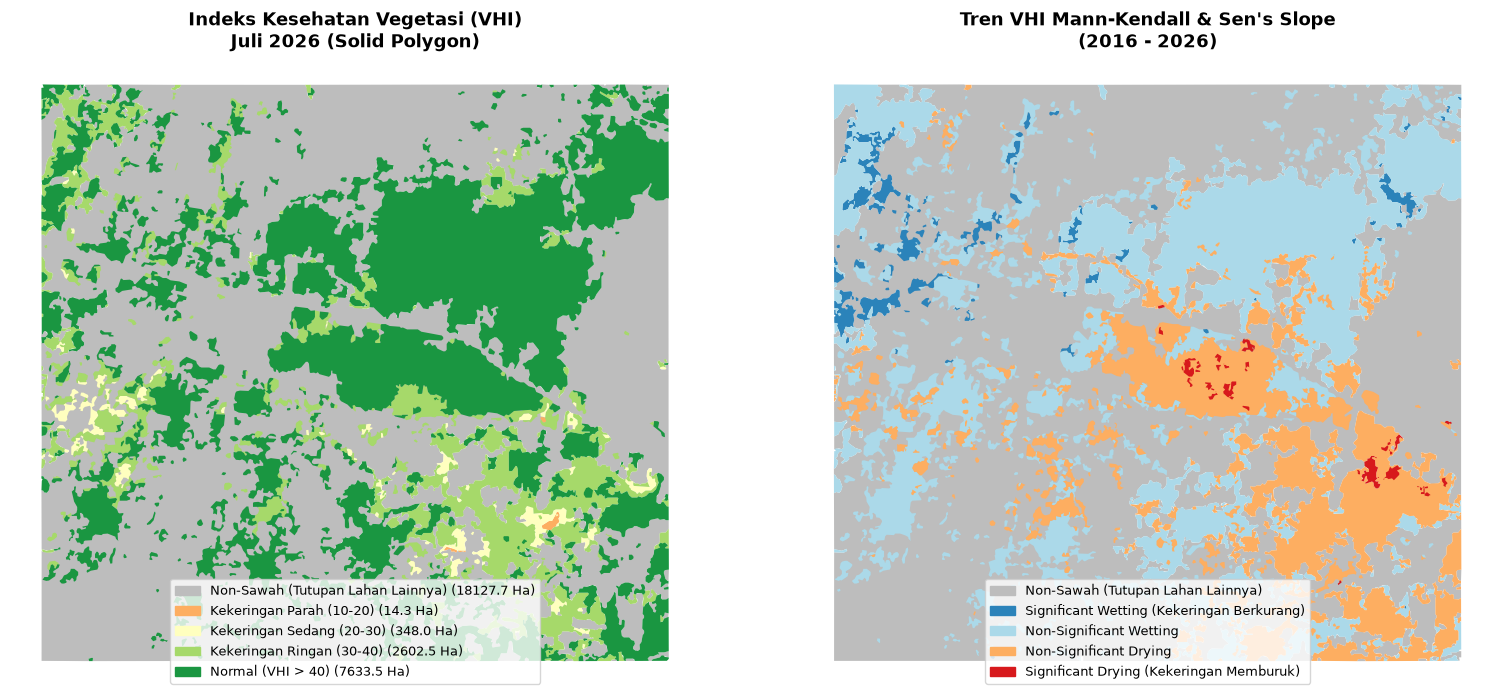


=== SEMUA PROSES, EKSPOR COG, GEOJSON, DAN METADATA INDEKS SELESAI ===


In [8]:
import os, json, warnings, datetime
import numpy as np
import geopandas as gpd
from shapely.geometry import box, shape as shapely_shape, Polygon, MultiPolygon
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rioxarray
import xarray as xr
import ee
import requests
import rasterio
from rasterio.features import shapes as rio_shapes
from rasterio.features import sieve as rio_sieve
from scipy.stats import pearsonr, fisk, norm
from scipy.ndimage import convolve

# --- OPSIONAL: majority filter pasca-klasifikasi, sebelum sieve ---
TERAPKAN_MAJORITY_FILTER = True
UKURAN_JENDELA_MAJORITY = 5

warnings.filterwarnings('ignore')

# ==============================================================================
# 1. KONFIGURASI PARAMETER
# ==============================================================================
PROJECT_ID = "poetic-emblem-487109-t6"  # Sesuaikan dengan Project ID Anda

RAW_DIR = "../../data/raw"
PROCESSED_DIR = "../../data/processed"
FIGURES_DIR = "../../results/figures/module_3"
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

FILE_SAWAH = os.path.join(PROCESSED_DIR, "module_1", "Klasifikasi_Sawah.tif")
MODULE_DIR = os.path.join(PROCESSED_DIR, "module_3")
os.makedirs(MODULE_DIR, exist_ok=True)

TAHUN_AWAL_ANALISIS = 2016
TAHUN_AKHIR_ANALISIS = 2026
BULAN_ANALISIS = 7  # Juli

JENDELA_BULAN = 1
CLOUD_TIERS_BASELINE = [40, 60, 80, 100]
MIN_CITRA_BASELINE = 15
BULAN_BAWAH = max(1, BULAN_ANALISIS - JENDELA_BULAN)
BULAN_ATAS = min(12, BULAN_ANALISIS + JENDELA_BULAN)

NODATA = 255
VHI_SENTINEL_INVALID = -1
TOLERANSI_SIMPLIFY_M = 15
MMU_LUAS_HA = 0.5  # Minimum Mapping Unit

# --- Kelas VHI ---
# NB: kelas 0 = "Non-Sawah" ditambahkan supaya seluruh piksel di dalam
# domain raster (bukan hanya sawah) punya nilai/warna saat ditampilkan di web
# (tidak kosong/putih lagi).
KELAS_VHI = {
    0: "Non-Sawah (Tutupan Lahan Lainnya)",
    1: "Kekeringan Ekstrem (VHI <= 10)",
    2: "Kekeringan Parah (10-20)",
    3: "Kekeringan Sedang (20-30)",
    4: "Kekeringan Ringan (30-40)",
    5: "Normal (VHI > 40)",
}
RENTANG_VHI = {0: "-", 1: "0 - 10", 2: "10 - 20", 3: "20 - 30", 4: "30 - 40", 5: "> 40"}
WARNA_VHI = {0: "#BDBDBD", 1: "#D7191C", 2: "#FDAE61", 3: "#FFFFBF", 4: "#A6D96A", 5: "#1A9641"}

# Keterangan per kelas VHI -- ditulis ke properti GeoJSON supaya bisa dipakai
# sebagai teks pop-up/tooltip saat kursor hover di atas poligon pada peta web.
KETERANGAN_VHI = {
    0: ("Bukan lahan sawah (tutupan/penggunaan lahan lain: permukiman, tegalan/ladang, hutan, "
        "badan air, dll). Area ini di-mask dan tidak diikutkan dalam analisis kekeringan VHI."),
    1: ("VHI <= 10. Kekeringan EKSTREM: kondisi vegetasi paling kering dibanding rekaman "
        "historis pada piksel yang sama. Risiko gagal panen sangat tinggi, perlu tindakan "
        "mitigasi segera (mis. irigasi darurat)."),
    2: ("10 < VHI <= 20. Kekeringan PARAH: vegetasi mengalami tekanan air yang signifikan."),
    3: ("20 < VHI <= 30. Kekeringan SEDANG: mulai terindikasi stres vegetasi, perlu "
        "pemantauan lanjutan."),
    4: ("30 < VHI <= 40. Kekeringan RINGAN: kondisi sedikit di bawah normal."),
    5: ("VHI > 40. NORMAL/sehat: tidak terindikasi kekeringan yang signifikan."),
}

# Definisi umum & manfaat indeks VHI -- ditulis sekali per layer (properti
# "definisi_indeks" / "manfaat_indeks") dan juga diekspor terpisah sebagai
# file metadata JSON untuk membangun panel info/legenda di website.
INFO_VHI = {
    "definisi": (
        "Vegetation Health Index (VHI) adalah indeks kesehatan vegetasi hasil kombinasi dua "
        "komponen: (1) Vegetation Condition Index (VCI), yaitu kondisi kehijauan vegetasi "
        "(NDVI) relatif terhadap nilai maksimum-minimum historisnya, dan (2) Temperature "
        "Condition Index (TCI), yaitu kondisi suhu permukaan lahan (LST) relatif terhadap "
        "nilai historisnya. Formula: VHI = (alpha x VCI) + ((1 - alpha) x TCI). Bobot alpha "
        "dioptimasi otomatis oleh skrip ini dengan mencari korelasi tertinggi terhadap proxy "
        "SPEI (Standardized Precipitation Evapotranspiration Index) yang dibangun dari data "
        "curah hujan CHIRPS dan evapotranspirasi potensial MODIS PET."
    ),
    "manfaat": (
        "Digunakan untuk mendeteksi & memetakan tingkat kekeringan pertanian (agricultural "
        "drought) pada lahan sawah secara spasial. Nilai VHI rendah menandakan vegetasi "
        "mengalami stres/kekeringan (kehijauan menurun & suhu meningkat dibanding kondisi "
        "historis), sedangkan nilai tinggi menandakan kondisi vegetasi sehat/normal. Peta ini "
        "dapat dipakai sebagai dasar peringatan dini kekeringan dan prioritas bantuan/irigasi."
    ),
}

# --- Kelas Tren Sen's Slope & Mann Kendall ---
LABEL_TREND = {
    0: "Non-Sawah (Tutupan Lahan Lainnya)",
    1: "Significant Wetting (Kekeringan Berkurang)",
    2: "Non-Significant Wetting",
    3: "Non-Significant Drying",
    4: "Significant Drying (Kekeringan Memburuk)"
}
RENTANG_TREND = {
    0: "-",
    1: "slope > 0, p <= 0.05",
    2: "slope > 0, p > 0.05",
    3: "slope <= 0, p > 0.05",
    4: "slope <= 0, p <= 0.05"
}
WARNA_TREND = {0: "#BDBDBD", 1: "#2B83BA", 2: "#ABD9E9", 3: "#FDAE61", 4: "#D7191C"}

KETERANGAN_TREND = {
    0: ("Bukan lahan sawah (tutupan/penggunaan lahan lain). Area ini tidak diikutkan dalam "
        "analisis tren VHI."),
    1: ("Slope > 0 dan p <= 0.05: tren MEMBAIK secara signifikan (kekeringan berkurang dari "
        "tahun ke tahun, valid secara statistik)."),
    2: ("Slope > 0 dan p > 0.05: tren membaik namun TIDAK signifikan secara statistik "
        "(kemungkinan hanya variasi alami)."),
    3: ("Slope <= 0 dan p > 0.05: tren memburuk namun TIDAK signifikan secara statistik."),
    4: ("Slope <= 0 dan p <= 0.05: tren MEMBURUK secara signifikan (kekeringan meningkat dari "
        "tahun ke tahun, valid secara statistik) -- area prioritas perhatian."),
}

INFO_TREND = {
    "definisi": (
        f"Peta tren VHI dihasilkan dari analisis deret waktu (time-series) VHI tahunan bulan "
        f"Juli periode {TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}, menggunakan uji "
        "non-parametrik Mann-Kendall untuk menentukan signifikansi statistik arah tren "
        "(p-value), dikombinasikan dengan Sen's Slope Estimator untuk menghitung besaran/laju "
        "perubahan VHI per tahun (unit VHI/tahun)."
    ),
    "manfaat": (
        "Digunakan untuk mengidentifikasi area sawah yang kondisinya membaik (wetting) atau "
        "memburuk (drying) secara konsisten dalam jangka panjang, sehingga dapat menjadi dasar "
        "prioritas intervensi/kebijakan -- misalnya pembangunan infrastruktur irigasi pada area "
        "dengan tren 'Significant Drying'."
    ),
}

# ==============================================================================
# 2. INISIALISASI GEE & MASKING SAWAH
# ==============================================================================
print("=== TAHAP 1: Inisialisasi GEE & Membaca Masking Sawah ===")
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

da_sawah = rioxarray.open_rasterio(FILE_SAWAH).squeeze(drop=True)
mask_sawah = (da_sawah.values == 1)
crs_epsg = da_sawah.rio.crs.to_epsg()
bounds_utm = da_sawah.rio.bounds()

# --- Masking Non-Sawah ---
# Semua piksel yang berada di dalam domain valid raster FILE_SAWAH (bukan
# nodata di luar area kajian) tetapi BUKAN kelas sawah (nilai != 1) akan
# ditandai sebagai "Non-Sawah" (mask_non_sawah). Nantinya piksel ini diberi
# kelas 0 pada hasil klasifikasi VHI & Tren agar tidak kosong/putih saat
# ditampilkan sebagai layer di website (tampil abu-abu).
nodata_sawah = da_sawah.rio.nodata
if nodata_sawah is not None:
    if np.issubdtype(da_sawah.values.dtype, np.floating) and np.isnan(nodata_sawah):
        domain_valid = ~np.isnan(da_sawah.values)
    else:
        domain_valid = (da_sawah.values != nodata_sawah)
else:
    domain_valid = np.ones(da_sawah.shape, dtype=bool)
mask_non_sawah = domain_valid & (~mask_sawah)
print(f"   Piksel sawah: {int(mask_sawah.sum()):,} | "
      f"Piksel non-sawah (akan diberi kelas 'Non-Sawah'): {int(mask_non_sawah.sum()):,}")

gdf_bounds = gpd.GeoDataFrame(geometry=[box(*bounds_utm)], crs=f"EPSG:{crs_epsg}")
wgs_bounds = gdf_bounds.to_crs("EPSG:4326").total_bounds
aoi_ee = ee.Geometry.Rectangle([wgs_bounds[0], wgs_bounds[1], wgs_bounds[2], wgs_bounds[3]])

res_x, res_y = da_sawah.rio.resolution()
luas_piksel_ha = abs(res_x * res_y) / 10000
MIN_SIEVE_PIXEL = max(1, int(round(MMU_LUAS_HA / luas_piksel_ha)))
print(f"   Resolusi grid kerja: {abs(res_x):.2f} x {abs(res_y):.2f} m "
      f"({luas_piksel_ha:.4f} Ha/piksel) -> MMU {MMU_LUAS_HA} Ha \u2248 {MIN_SIEVE_PIXEL} piksel.")

# ==============================================================================
# 3. FUNGSI GEE SERVER-SIDE
# ==============================================================================
print(f"\n=== TAHAP 2: Menghitung Baseline Max/Min Historis (Juli {TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}) ===")

def mask_l89_clouds(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud = 1 << 1
    cloud = 1 << 3
    cloud_shadow = 1 << 4
    mask = qa.bitwiseAnd(cloud).eq(0) \
             .And(qa.bitwiseAnd(cloud_shadow).eq(0)) \
             .And(qa.bitwiseAnd(dilated_cloud).eq(0))
    return image.updateMask(mask)

def add_indices(image):
    img_masked = mask_l89_clouds(image)
    opt = img_masked.select(['SR_B4', 'SR_B5']).multiply(0.0000275).add(-0.2)
    ndvi = opt.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
    lst = img_masked.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST')
    return img_masked.addBands([ndvi, lst])

def bangun_koleksi_baseline(bulan_bawah, bulan_atas, cloud_tiers=CLOUD_TIERS_BASELINE, min_citra=MIN_CITRA_BASELINE):
    gab, cmax, n = None, cloud_tiers[-1], 0
    for cmax in cloud_tiers:
        l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', cmax))
              .filter(ee.Filter.calendarRange(bulan_bawah, bulan_atas, 'month'))
              .filter(ee.Filter.calendarRange(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
        l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', cmax))
              .filter(ee.Filter.calendarRange(bulan_bawah, bulan_atas, 'month'))
              .filter(ee.Filter.calendarRange(max(TAHUN_AWAL_ANALISIS, 2021), TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
        gab = l8.merge(l9)
        n = gab.size().getInfo()
        if n >= min_citra:
            break
    return gab, cmax, n

hist_col, cloud_max_terpakai, n_hist_col = bangun_koleksi_baseline(BULAN_BAWAH, BULAN_ATAS)

ndvi_max = hist_col.select('NDVI').max()
ndvi_min = hist_col.select('NDVI').min()
lst_max = hist_col.select('LST').max()
lst_min = hist_col.select('LST').min()

l8_bulanan = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', 40))
              .filter(ee.Filter.calendarRange(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
l9_bulanan = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(aoi_ee)
              .filter(ee.Filter.lt('CLOUD_COVER', 40))
              .filter(ee.Filter.calendarRange(max(TAHUN_AWAL_ANALISIS, 2021), TAHUN_AKHIR_ANALISIS, 'year'))
              .map(add_indices))
hist_col_bulanan = l8_bulanan.merge(l9_bulanan)

ndvi_max_kal = hist_col_bulanan.select('NDVI').max()
ndvi_min_kal = hist_col_bulanan.select('NDVI').min()
lst_max_kal = hist_col_bulanan.select('LST').max()
lst_min_kal = hist_col_bulanan.select('LST').min()

# ==============================================================================
# 4. OPTIMASI NILAI ALPHA MENGGUNAKAN PROXY SPEI
# ==============================================================================
print("\n=== TAHAP 3: Optimasi Bobot Alpha (\u03B1) menggunakan Proxy SPEI ===")

chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY")
modis_pet_col = ee.ImageCollection("MODIS/061/MOD16A2")

citra_chirps_terakhir = chirps.sort('system:time_start', False).first()
tgl_chirps_ms = ee.Date(citra_chirps_terakhir.get('system:time_start')).getInfo()['value']
citra_modis_terakhir = modis_pet_col.sort('system:time_start', False).first()
tgl_modis_ms = ee.Date(citra_modis_terakhir.get('system:time_start')).getInfo()['value']

tgl_chirps_terakhir = datetime.datetime.utcfromtimestamp(tgl_chirps_ms / 1000).date()
tgl_modis_terakhir = datetime.datetime.utcfromtimestamp(tgl_modis_ms / 1000).date()
batas_bulan_data = min(tgl_chirps_terakhir, tgl_modis_terakhir).replace(day=1)

kombinasi_tahun_bulan = []
for th in range(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS + 1):
    for bl in range(1, 13):
        if datetime.date(th, bl, 1) < batas_bulan_data:
            kombinasi_tahun_bulan.append([th, bl])

def get_monthly_means(pasangan):
    pasangan = ee.List(pasangan)
    y = ee.Number(pasangan.get(0))
    m = ee.Number(pasangan.get(1))
    t_awal = ee.Date.fromYMD(y, m, 1)
    t_akhir = t_awal.advance(1, 'month')

    col_bulan = hist_col_bulanan.filterDate(t_awal, t_akhir)
    img = ee.Image(ee.Algorithms.If(
        col_bulan.size().gt(0),
        col_bulan.median(),
        ee.Image.constant([0, 0]).rename(['NDVI', 'LST']).updateMask(0)
    ))

    vci = img.select('NDVI').subtract(ndvi_min_kal).divide(ndvi_max_kal.subtract(ndvi_min_kal)).multiply(100)
    tci = lst_max_kal.subtract(img.select('LST')).divide(lst_max_kal.subtract(lst_min_kal)).multiply(100)

    c_col = chirps.filterDate(t_awal, t_akhir)
    pr_bulan = ee.Image(ee.Algorithms.If(
        c_col.size().gt(0),
        c_col.select('precipitation').sum(),
        ee.Image.constant(0).rename('precipitation').updateMask(0)
    )).rename('PR')

    m_col = modis_pet_col.filterDate(t_awal, t_akhir)
    pet_bulan = ee.Image(ee.Algorithms.If(
        m_col.size().gt(0),
        m_col.select('PET').sum().multiply(0.1),
        ee.Image.constant(0).rename('PET').updateMask(0)
    )).rename('PET')

    wb = pr_bulan.subtract(pet_bulan).rename('WB')

    means = ee.Image([vci.rename('VCI'), tci.rename('TCI'), wb]) \
              .reduceRegion(reducer=ee.Reducer.mean(), geometry=aoi_ee, scale=100, maxPixels=1e9)

    props = ee.Dictionary(ee.Algorithms.If(col_bulan.size().gt(0), means, ee.Dictionary({})))
    return ee.Feature(None, props).set({'year': y, 'month': m})

kombinasi_ee = ee.List(kombinasi_tahun_bulan)
ts_features = ee.FeatureCollection(kombinasi_ee.map(get_monthly_means)).getInfo()

vci_arr, tci_arr, wb_arr = [], [], []
for f in ts_features['features']:
    props = f['properties']
    if props.get('VCI') is not None and props.get('WB') is not None:
        vci_arr.append(props['VCI']); tci_arr.append(props['TCI']); wb_arr.append(props['WB'])

vci_arr, tci_arr, wb_arr = np.array(vci_arr), np.array(tci_arr), np.array(wb_arr)

try:
    par_fisk = fisk.fit(wb_arr)
    cdf_wb = fisk.cdf(wb_arr, *par_fisk)
    cdf_wb = np.clip(cdf_wb, 1e-6, 1 - 1e-6)
    spei_proxy_arr = norm.ppf(cdf_wb)
except Exception:
    spei_proxy_arr = (wb_arr - wb_arr.mean()) / wb_arr.std()

alpha_range = np.arange(0.0, 1.01, 0.05)
correlations = []
for a in alpha_range:
    vhi_test = (a * vci_arr) + ((1 - a) * tci_arr)
    corr, _ = pearsonr(vhi_test, spei_proxy_arr)
    correlations.append(corr)

best_alpha = alpha_range[np.argmax(correlations)]
print(f"-> Bobot Alpha optimal didapatkan: {best_alpha:.2f}")

# ==============================================================================
# 5. TREN VHI PER TAHUN
# ==============================================================================
print(f"\n=== TAHAP 4: Menghitung Tren VHI per Tahun ({TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}) ===")
MIN_TAHUN_VALID_TREND = 4

def unduh_vhi_tahun(tahun, scale=30):
    col = hist_col.filter(ee.Filter.calendarRange(tahun, tahun, 'year'))
    n_citra = col.size().getInfo()
    if n_citra == 0:
        return None, 0

    img = col.median()
    vci = img.select('NDVI').subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100)
    tci = lst_max.subtract(img.select('LST')).divide(lst_max.subtract(lst_min)).multiply(100)
    vhi_img = vci.multiply(best_alpha).add(tci.multiply(1 - best_alpha)).rename('VHI') \
                 .unmask(VHI_SENTINEL_INVALID)

    url = vhi_img.getDownloadURL({'scale': scale, 'crs': f'EPSG:{crs_epsg}', 'region': aoi_ee, 'format': 'GEO_TIFF'})
    path_tif = f"temp_vhi_{tahun}.tif"
    with open(path_tif, "wb") as f:
        f.write(requests.get(url).content)

    da_raw = rioxarray.open_rasterio(path_tif)
    da = da_raw.rio.reproject_match(da_sawah)
    arr = da.values[0].astype(np.float32)
    arr = np.where(arr < 0, np.nan, arr)
    da_raw.close()
    os.remove(path_tif)
    return arr, n_citra

tahun_list = list(range(TAHUN_AWAL_ANALISIS, TAHUN_AKHIR_ANALISIS + 1))
stack_tahun = [unduh_vhi_tahun(th)[0] for th in tahun_list]
stack_tahun = [np.full(da_sawah.shape, np.nan, dtype=np.float32) if a is None else a for a in stack_tahun]
stack_vhi_tahunan = np.stack(stack_tahun)
tahun_arr = np.array(tahun_list, dtype=np.float64)

def hitung_mk_dan_sen(stack, tahun, min_titik=MIN_TAHUN_VALID_TREND):
    n_tahun = stack.shape[0]
    n_valid = np.sum(~np.isnan(stack), axis=0)

    daftar_sign, daftar_slope = [], []
    for i in range(n_tahun):
        for j in range(i + 1, n_tahun):
            beda_y = stack[j] - stack[i]
            beda_x = tahun[j] - tahun[i]
            pasangan_valid = ~np.isnan(beda_y)
            daftar_sign.append(np.where(pasangan_valid, np.sign(beda_y), np.nan))
            daftar_slope.append(np.where(pasangan_valid, beda_y / beda_x, np.nan))

    S = np.nansum(np.stack(daftar_sign), axis=0)
    sen_slope = np.nanmedian(np.stack(daftar_slope), axis=0)

    varS = (n_valid * (n_valid - 1) * (2 * n_valid + 5)) / 18.0
    with np.errstate(invalid="ignore", divide="ignore"):
        z = np.where(S > 0, (S - 1) / np.sqrt(varS),
           np.where(S < 0, (S + 1) / np.sqrt(varS), 0.0))
    p_value = 2 * (1 - norm.cdf(np.abs(z)))

    tdk_cukup_data = n_valid < min_titik
    sen_slope = np.where(tdk_cukup_data, np.nan, sen_slope)
    p_value = np.where(tdk_cukup_data, np.nan, p_value)
    return sen_slope, p_value, n_valid

sen_slope, p_value, n_valid_tren = hitung_mk_dan_sen(stack_vhi_tahunan, tahun_arr)

trend_class = np.full(sen_slope.shape, np.nan)
valid_trend = mask_sawah & ~np.isnan(sen_slope) & ~np.isnan(p_value)
trend_class[valid_trend & (sen_slope > 0) & (p_value <= 0.05)] = 1
trend_class[valid_trend & (sen_slope > 0) & (p_value > 0.05)] = 2
trend_class[valid_trend & (sen_slope <= 0) & (p_value > 0.05)] = 3
trend_class[valid_trend & (sen_slope <= 0) & (p_value <= 0.05)] = 4
# Non-sawah -> kelas 0, supaya seluruh domain raster punya nilai (tidak kosong)
trend_class[mask_non_sawah] = 0

print(f"Menarik citra VHI terbaru Juli {TAHUN_AKHIR_ANALISIS}...")
img_terbaru = hist_col.filter(ee.Filter.calendarRange(TAHUN_AKHIR_ANALISIS, TAHUN_AKHIR_ANALISIS, 'year')).median()
vci_terbaru = img_terbaru.select('NDVI').subtract(ndvi_min).divide(ndvi_max.subtract(ndvi_min)).multiply(100)
tci_terbaru = lst_max.subtract(img_terbaru.select('LST')).divide(lst_max.subtract(lst_min)).multiply(100)

vhi_terbaru_img = vci_terbaru.multiply(best_alpha).add(tci_terbaru.multiply(1 - best_alpha)).rename('VHI') \
    .unmask(VHI_SENTINEL_INVALID)

url_terbaru = vhi_terbaru_img.getDownloadURL({'scale': 30, 'crs': f'EPSG:{crs_epsg}', 'region': aoi_ee, 'format': 'GEO_TIFF'})
with open("temp_vhi_terbaru.tif", "wb") as f:
    f.write(requests.get(url_terbaru).content)

# ==============================================================================
# 6. KLASIFIKASI KEKERINGAN LOKAL & SIEVE FILTER
# ==============================================================================
print("\n=== TAHAP 5: Penyelarasan Masking Lahan Sawah & Sieve Filter ===")
da_vhi_raw = rioxarray.open_rasterio("temp_vhi_terbaru.tif")
da_vhi = da_vhi_raw.rio.reproject_match(da_sawah)
vhi_arr = np.where(mask_sawah, da_vhi.values[0], np.nan)
vhi_arr = np.where(vhi_arr < 0, np.nan, vhi_arr)

kelas_arr = np.full(vhi_arr.shape, np.nan)
kelas_arr[(vhi_arr >= 0) & (vhi_arr <= 10)] = 1
kelas_arr[(vhi_arr > 10) & (vhi_arr <= 20)] = 2
kelas_arr[(vhi_arr > 20) & (vhi_arr <= 30)] = 3
kelas_arr[(vhi_arr > 30) & (vhi_arr <= 40)] = 4
kelas_arr[(vhi_arr > 40)] = 5
# Non-sawah -> kelas 0, supaya seluruh domain raster punya nilai (tidak kosong)
kelas_arr[mask_non_sawah] = 0

da_vhi_raw.close()
if os.path.exists("temp_vhi_terbaru.tif"):
    os.remove("temp_vhi_terbaru.tif")

def majority_filter_kelas(kelas_arr_in, ukuran_jendela=5):
    """
    Majority filter (mode) utk array kelas kategorikal (float, NaN = piksel
    invalid) -- dipakai utk kelas_arr (VHI, termasuk kelas Non-Sawah) &
    trend_class (Tren, termasuk kelas Non-Sawah).
    Piksel NaN tidak ikut dihitung sbg tetangga & tetap NaN pd hasil akhir.
    """
    mask_valid = ~np.isnan(kelas_arr_in)
    kelas_ada = np.unique(kelas_arr_in[mask_valid]).astype(int)
    if kelas_ada.size == 0:
        return kelas_arr_in.copy()

    kernel = np.ones((ukuran_jendela, ukuran_jendela), dtype=np.float32)
    tumpukan_count = np.zeros((len(kelas_ada),) + kelas_arr_in.shape, dtype=np.float32)

    for i, k in enumerate(kelas_ada):
        biner_k = ((kelas_arr_in == k) & mask_valid).astype(np.float32)
        tumpukan_count[i] = convolve(biner_k, kernel, mode="constant", cval=0)

    idx_menang = np.argmax(tumpukan_count, axis=0)
    hasil = kelas_ada[idx_menang].astype(float)
    hasil[~mask_valid] = np.nan
    return hasil

def terapkan_sieve(kelas_arr_in, min_piksel=MIN_SIEVE_PIXEL, connectivity=8, nama=""):
    if np.all(np.isnan(kelas_arr_in)):
        return kelas_arr_in
    kelas_u8 = np.where(np.isnan(kelas_arr_in), NODATA, kelas_arr_in).astype(np.uint8)
    kelas_sieved = rio_sieve(kelas_u8, size=min_piksel, connectivity=connectivity)
    return np.where(kelas_sieved == NODATA, np.nan, kelas_sieved).astype(np.float32)

if TERAPKAN_MAJORITY_FILTER:
    print(f"   -> Menerapkan majority filter {UKURAN_JENDELA_MAJORITY}x{UKURAN_JENDELA_MAJORITY} "
          f"pada kelas VHI & tren...")
    kelas_arr = majority_filter_kelas(kelas_arr, ukuran_jendela=UKURAN_JENDELA_MAJORITY)
    trend_class = majority_filter_kelas(trend_class, ukuran_jendela=UKURAN_JENDELA_MAJORITY)

kelas_arr = terapkan_sieve(kelas_arr, nama=f"VHI_Juli{TAHUN_AKHIR_ANALISIS}")
trend_class = terapkan_sieve(trend_class, nama=f"Tren_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}")

# ==============================================================================
# 6B. FUNGSI EKSPOR COG (Cloud-Optimized GeoTIFF)
# ==============================================================================
def ekspor_ke_cog(arr_data, path_cog, transform, crs, nodata_val=255):
    """Menyimpan array numpy sebagai file COG (Cloud-Optimized GeoTIFF)"""
    arr_out = np.where(np.isnan(arr_data), nodata_val, arr_data)
    if np.issubdtype(arr_out.dtype, np.floating):
        arr_out = arr_out.astype(np.float32)
    elif np.issubdtype(arr_out.dtype, np.integer):
        arr_out = arr_out.astype(np.uint8)

    height, width = arr_out.shape
    profile = {
        'driver': 'COG',
        'height': height,
        'width': width,
        'count': 1,
        'dtype': arr_out.dtype,
        'crs': crs,
        'transform': transform,
        'nodata': nodata_val,
        'compress': 'DEFLATE',
        'blocksize': 256
    }
    with rasterio.open(path_cog, 'w', **profile) as dst:
        dst.write(arr_out, 1)
    print(f"   -> COG tersimpan: {path_cog}")

path_cog_vhi = f"Raster_VHI_Juli{TAHUN_AKHIR_ANALISIS}.tif"
ekspor_ke_cog(kelas_arr, path_cog_vhi, da_sawah.rio.transform(), da_sawah.rio.crs, nodata_val=NODATA)

path_cog_trend = f"Raster_Trend_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}.tif"
ekspor_ke_cog(trend_class, path_cog_trend, da_sawah.rio.transform(), da_sawah.rio.crs, nodata_val=NODATA)


# ==============================================================================
# 7. POLIGONISASI + PENGHILANGAN LOBANG (HOLES REMOVAL) + EKSPOR GEOJSON
# ==============================================================================
print("\n=== TAHAP 6: Poligonisasi, Pembersihan Lubang (Holes), & Ekspor GeoJSON ===")

def remove_holes(geom):
    """Menghilangkan lubang/interior rings pada poligon agar solid/tidak bolong-bolong"""
    if geom.is_empty:
        return geom
    if isinstance(geom, Polygon):
        return Polygon(geom.exterior)
    elif isinstance(geom, MultiPolygon):
        return MultiPolygon([Polygon(p.exterior) for p in geom.geoms])
    return geom

def poligonisasi_kelas_ke_geojson(kelas_arr_in, transform, crs, dict_label, dict_rentang,
                                   dict_warna, dict_keterangan, info_indeks,
                                   nama_layer, path_out, toleransi_simplify_m=TOLERANSI_SIMPLIFY_M):
    kelas_u8 = np.where(np.isnan(kelas_arr_in), NODATA, kelas_arr_in).astype(np.uint8)

    records = [
        {"kelas": int(val), "geometry": shapely_shape(geom)}
        for geom, val in rio_shapes(kelas_u8, mask=(kelas_u8 != NODATA), transform=transform, connectivity=8)
    ]
    if not records:
        print(f"   [Peringatan] {nama_layer}: tidak ada fitur terpoligonisasi.")
        return None

    gdf = gpd.GeoDataFrame(records, crs=crs)
    gdf = gdf.dissolve(by="kelas", as_index=False)

    if toleransi_simplify_m and toleransi_simplify_m > 0:
        gdf["geometry"] = gdf["geometry"].simplify(toleransi_simplify_m, preserve_topology=True)

    # >> PERBAIKAN UTAMA: Menghilangkan lubang interior (interior rings) & buffer(0)
    gdf["geometry"] = gdf["geometry"].apply(remove_holes)
    gdf["geometry"] = gdf["geometry"].buffer(0)

    gdf["luas_ha"] = (gdf.geometry.area / 10000).round(2)
    gdf["label"] = gdf["kelas"].map(dict_label)
    gdf["rentang_nilai"] = gdf["kelas"].map(dict_rentang)
    gdf["warna"] = gdf["kelas"].map(dict_warna)
    # Properti "keterangan" -> teks per kelas yang bisa langsung dipakai front-end
    # (Leaflet/Mapbox dsb.) sebagai isi popup/tooltip saat kursor hover pada poligon.
    gdf["keterangan"] = gdf["kelas"].map(dict_keterangan)
    gdf["indeks"] = nama_layer
    gdf["definisi_indeks"] = info_indeks["definisi"]
    gdf["manfaat_indeks"] = info_indeks["manfaat"]

    gdf = gdf.to_crs("EPSG:4326")
    gdf.to_file(path_out, driver="GeoJSON")

    ukuran_kb = os.path.getsize(path_out) / 1024
    print(f"   -> {nama_layer}: GeoJSON solid tersimpan ({len(gdf)} fitur kelas, {ukuran_kb:,.0f} KB)")
    return gdf

def ekspor_metadata_indeks(path_out, nama_indeks, info_indeks, dict_label, dict_rentang, dict_warna, dict_keterangan):
    """
    Mengekspor metadata indeks (definisi, manfaat, & rincian tiap kelas beserta
    warnanya) sebagai file JSON terpisah. File ini dipakai front-end website
    untuk membangun panel legenda/info (mis. seperti panel NDVI pada contoh
    referensi) tanpa perlu menuliskan ulang deskripsi secara manual.
    """
    kelas_list = [
        {
            "kelas": k,
            "label": dict_label[k],
            "rentang_nilai": dict_rentang.get(k, "-"),
            "warna": dict_warna.get(k, "#BDBDBD"),
            "keterangan": dict_keterangan.get(k, ""),
        }
        for k in sorted(dict_label.keys())
    ]
    meta = {
        "nama_indeks": nama_indeks,
        "definisi": info_indeks["definisi"],
        "manfaat": info_indeks["manfaat"],
        "kelas": kelas_list,
    }
    with open(path_out, "w", encoding="utf-8") as f:
        json.dump(meta, f, ensure_ascii=False, indent=2)
    print(f"   -> Metadata indeks tersimpan: {path_out}")

path_geojson_vhi = os.path.join(MODULE_DIR, f"Peta_VHI_Juli{TAHUN_AKHIR_ANALISIS}.geojson")
gdf_vhi = poligonisasi_kelas_ke_geojson(
    kelas_arr, da_sawah.rio.transform(), da_sawah.rio.crs,
    KELAS_VHI, RENTANG_VHI, WARNA_VHI, KETERANGAN_VHI, INFO_VHI,
    f"VHI_Juli{TAHUN_AKHIR_ANALISIS}", path_geojson_vhi
)
ekspor_metadata_indeks(
    f"Info_Indeks_VHI_Juli{TAHUN_AKHIR_ANALISIS}.json",
    "Vegetation Health Index (VHI)", INFO_VHI, KELAS_VHI, RENTANG_VHI, WARNA_VHI, KETERANGAN_VHI
)

path_geojson_trend = os.path.join(MODULE_DIR, f"Peta_Trend_SensSlope_VHI_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}.geojson")
gdf_trend = poligonisasi_kelas_ke_geojson(
    trend_class, da_sawah.rio.transform(), da_sawah.rio.crs,
    LABEL_TREND, RENTANG_TREND, WARNA_TREND, KETERANGAN_TREND, INFO_TREND,
    f"Tren_VHI_SensSlope_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}", path_geojson_trend
)
ekspor_metadata_indeks(
    f"Info_Indeks_Trend_{TAHUN_AWAL_ANALISIS}-{TAHUN_AKHIR_ANALISIS}.json",
    "Tren VHI (Mann-Kendall & Sen's Slope)", INFO_TREND, LABEL_TREND, RENTANG_TREND, WARNA_TREND, KETERANGAN_TREND
)

for f in [f"temp_vhi_{th}.tif" for th in tahun_list]:
    if os.path.exists(f): os.remove(f)

# ==============================================================================
# 8. PRATINJAU HASIL
# ==============================================================================
print("\n=== TAHAP 7: Pratinjau Hasil ===")
luas_vhi = {}
if gdf_vhi is not None:
    for k in KELAS_VHI.keys():
        luas_vhi[k] = gdf_vhi.loc[gdf_vhi["kelas"] == k, "luas_ha"].sum() if k in gdf_vhi["kelas"].values else 0

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

if gdf_vhi is not None:
    # Kelas 0 (Non-Sawah) digambar lebih dulu supaya berada di lapisan paling
    # bawah dan tidak menutupi poligon kelas kekeringan sawah (1-5).
    for k in KELAS_VHI.keys():
        if k in gdf_vhi["kelas"].values:
            gdf_vhi[gdf_vhi["kelas"] == k].plot(ax=axes[0], color=WARNA_VHI[k], edgecolor="none")
    handles_vhi = [mpatches.Patch(color=WARNA_VHI[k], label=f"{KELAS_VHI[k]} ({luas_vhi[k]:.1f} Ha)")
                   for k in KELAS_VHI.keys() if luas_vhi[k] > 0]
    axes[0].legend(handles=handles_vhi, loc="lower center", fontsize=9)
    axes[0].set_title(f"Indeks Kesehatan Vegetasi (VHI)\nJuli {TAHUN_AKHIR_ANALISIS} (Solid Polygon)", fontsize=13, fontweight='bold')
axes[0].set_axis_off()

if gdf_trend is not None:
    for k in LABEL_TREND.keys():
        if k in gdf_trend["kelas"].values:
            gdf_trend[gdf_trend["kelas"] == k].plot(ax=axes[1], color=WARNA_TREND[k], edgecolor="none")
    handles_trend = [mpatches.Patch(color=WARNA_TREND[k], label=LABEL_TREND[k]) for k in LABEL_TREND.keys()]
    axes[1].legend(handles=handles_trend, loc="lower center", fontsize=9)
    axes[1].set_title(f"Tren VHI Mann-Kendall & Sen's Slope\n({TAHUN_AWAL_ANALISIS} - {TAHUN_AKHIR_ANALISIS})", fontsize=13, fontweight='bold')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()
print("\n=== SEMUA PROSES, EKSPOR COG, GEOJSON, DAN METADATA INDEKS SELESAI ===")